# Huấn luyện mô hình dự đoán nguy cơ thi trượt

## 1. Định nghĩa bài toán

### Mục tiêu
Xây dựng mô hình phân loại nhị phân nhằm dự báo nguy cơ sinh viên nhận
kết quả `Fail` tại từng snapshot tuần của học phần.

### Biến mục tiêu

- `Fail` → Positive (`1`).
- `Pass` và `Distinction` → Negative (`0`).
- `Withdrawn` bị loại khỏi dữ liệu huấn luyện vì rút học không đồng nghĩa
  với thi trượt.

### Đơn vị dự báo

- Kết quả 1 môn học của 1 sinh viên trong một tuần của một học kỳ.
- Tức là: 1 presentation - 1 module - 1 sinh viên - 1 week.
- Bắt đầu dự báo vào tuần thứ 2 đến tuần cuối cùng của học phần.

### Phương pháp chia dữ liệu:

- `2013B`: tập huấn luyện.
- `2013J`: tập validation để chọn feature, mô hình, tham số và threshold.
- `2014B`: tập test cuối.
- `2014J`: dữ liệu mô phỏng dự báo trong vận hành.

Không chia ngẫu nhiên vì mục tiêu là đánh giá khả năng dự báo trên
presentation xảy ra sau dữ liệu huấn luyện.

### Cột không đưa vào mô hình

- `id_student`: định danh sinh viên.
- `code_module`: giữ để phân tích kết quả theo học phần nhưng không dùng
  làm feature, nhằm hạn chế mô hình phụ thuộc vào mã môn cụ thể.
- `code_presentation`: dùng để temporal split.
- `final_result`: chỉ dùng để tạo target.



### Import thư viện và cấu hình notebook

In [96]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython import display
from tabulate import tabulate
from datetime import datetime
import wandb
import shap
import joblib as jb
from ml_pipeline.data_serving import get_train_data
from elt_pipeline.database import get_connection
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    average_precision_score,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    brier_score_loss,
    make_scorer
)
from sklearn.calibration import CalibrationDisplay
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, PredefinedSplit

RANDOM_STATE = 42
THRESHOLD = 0.5

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

### Lấy tập dữ liệu phục vụ huấn luyện từ data warehouse

In [16]:
df = pd.DataFrame()
with get_connection() as connection:
    df = get_train_data(connection)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 532324 entries, 0 to 532323
Data columns (total 25 columns):
 #   Column                               Non-Null Count   Dtype
---  ------                               --------------   -----
 0   module_presentation_student_week_id  532324 non-null  int64
 1   id_student                           532324 non-null  int64
 2   code_module                          532324 non-null  str  
 3   code_presentation                    532324 non-null  str  
 4   week_no                              532324 non-null  int64
 5   gender                               532324 non-null  str  
 6   region                               532324 non-null  str  
 7   highest_education                    532324 non-null  str  
 8   imd_band                             512254 non-null  str  
 9   age_band                             532324 non-null  str  
 10  disability                           532324 non-null  str  
 11  num_of_prev_attempts                 532324 non-nu

### Chia tập dữ liệu thành 3 tập con

In [17]:
train_df = df[df['code_presentation'] == "2013B"].copy()
val_df = df[df['code_presentation'] == "2013J"].copy()
test_df = df[df['code_presentation'] == "2014B"].copy()

print(f"Tổng kích thước: {df.shape}")
print(f"Kích thước tập huấn luyện: {train_df.shape}")
print(f"Kích thước tập tinh chỉnh: {val_df.shape}")
print(f"Kích thước tập kiểm tra: {test_df.shape}")

Tổng kích thước: (532324, 25)
Kích thước tập huấn luyện: (113392, 25)
Kích thước tập tinh chỉnh: (243600, 25)
Kích thước tập kiểm tra: (175332, 25)


## 2. Phân tích dữ liệu 2013B

Bước này chỉ phân tích dữ liệu trên presentation `2013B` tương đương với kỳ đầu tiên của năm 2013. Vì đây là phần dữ liệu sẽ được dùng để huấn luyện các mô hình.

### 2.1 Tổng quan

In [4]:
print(
    f"Train 2013B có "
    f"{train_df.shape[0]:,} dòng và "
    f"{train_df.shape[1]} cột."
)

display(train_df.head())

train_df.info()

Train 2013B có 113,392 dòng và 25 cột.


,module_presentation_student_week_id,id_student,code_module,code_presentation,week_no,gender,region,highest_education,imd_band,age_band,...,active_day_count_week,active_day_count_to_week,site_count_to_week,activity_type_count_to_week,coursework_due_count_to_week,coursework_submitted_count_week,coursework_submitted_count_to_week,coursework_late_count_to_week,coursework_overdue_count_to_week,final_result
5054,5409,537656,FFF,2013B,2,M,Ireland,HE Qualification,NaN,35-55,...,7,18,66,12,0,0,0,0,0,Pass
5055,5410,537656,FFF,2013B,3,M,Ireland,HE Qualification,NaN,35-55,...,7,25,74,12,1,3,3,0,0,Pass
5056,5411,537656,FFF,2013B,4,M,Ireland,HE Qualification,NaN,35-55,...,6,31,76,12,1,0,3,0,0,Pass
5057,5412,537656,FFF,2013B,5,M,Ireland,HE Qualification,NaN,35-55,...,3,34,76,12,1,0,3,0,0,Pass
5058,5413,537656,FFF,2013B,6,M,Ireland,HE Qualification,NaN,35-55,...,0,34,76,12,1,0,3,0,0,Pass


<class 'pandas.DataFrame'>
Index: 113392 entries, 5054 to 378380
Data columns (total 25 columns):
 #   Column                               Non-Null Count   Dtype
---  ------                               --------------   -----
 0   module_presentation_student_week_id  113392 non-null  int64
 1   id_student                           113392 non-null  int64
 2   code_module                          113392 non-null  str  
 3   code_presentation                    113392 non-null  str  
 4   week_no                              113392 non-null  int64
 5   gender                               113392 non-null  str  
 6   region                               113392 non-null  str  
 7   highest_education                    113392 non-null  str  
 8   imd_band                             108496 non-null  str  
 9   age_band                             113392 non-null  str  
 10  disability                           113392 non-null  str  
 11  num_of_prev_attempts                 113392 non-null

=> Tập dữ liệu có `113,392` dòng và `25` thuộc tính được lấy từ data warehouse và đã được kiểm tra lỗi về:
- lỗi kiểu dữ liệu.
- lỗi dòng trùng.
- lỗi giá trị âm của các cột numeric.
- lỗi sai ý nghĩa các dòng tích luỹ (giá trị tích luỹ luôn lớn hơn giá trị tuần)

### 2.2. Phân phối biến mục tiêu

In [18]:
target_map = {
    "Fail" : 1,
    "Pass" : 0,
    "Distinction" : 0,
}

tmp_df = train_df['final_result'].copy()

tmp_df = tmp_df.map(target_map)

print(tmp_df.value_counts())

final_result
0    71215
1    42177
Name: count, dtype: int64


Text(0.5, 1.0, 'biểu đồ tỉ lệ lớp của tập huấn luyện')

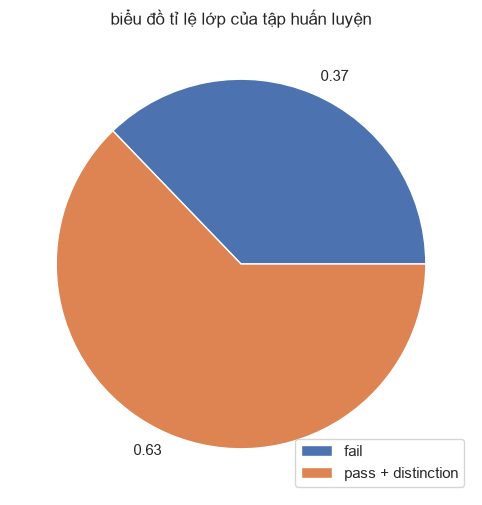

In [19]:
train_count = len(train_df)

pos_rate = tmp_df.value_counts()[1].astype(int) / train_count
neg_rate = tmp_df.value_counts()[0].astype(int) / train_count

plt.figure(figsize=(10, 6))
plt.pie([pos_rate, neg_rate], labels=[pos_rate.round(2), neg_rate.round(2)])
plt.legend([ 'fail', 'pass + distinction'])
plt.title("biểu đồ tỉ lệ lớp của tập huấn luyện")

Trong tập huấn luyện `2013B`, lớp `Fail` chiếm khoảng 37%, còn
`Pass + Distinction` chiếm khoảng 63% số mẫu.

=> Có sự chênh lệch 26% giữa hai lớp trong tập này. Dữ liệu có mất cân bằng lớp ở mức vừa phải. Vì vậy, chưa tự động áp dụng kỹ thuật cân bằng dữ liệu; cần so sánh mô hình mặc định với
`class_weight="balanced"` trên tập validation `2013J`.

### 2.3 Phân tích giá trị thiếu

Do bộ dữ liệu được kiểm tra trước khi nạp từ data warehouse, nên chỉ có duy nhất 1 thuộc tính được phép chứa giá trị `null` là `imd_band`.

Phần phân tích giá trị thiếu sẽ tập trung phân tích vào thuộc tính này.

In [20]:
missing = {}
missing_rate = {}

for col in train_df.columns:
    missing[col] = train_df[col].isnull().sum()

for key in missing.keys():
    missing_rate[key] = missing[key] / train_count


print("Các thuộc tính có missing value:")
for key, val in missing.items():
    if val > 0:
        print(f"{key} : {val} dòng ")
        print(f"{key} : {missing_rate[key].round(2) * 100} % ")

Các thuộc tính có missing value:
imd_band : 4896 dòng 
imd_band : 4.0 % 


=> chỉ có thuộc tính `imd_band` chứa giá trị thiếu,
gồm 4.896 dòng, tương đương 4% số mẫu. Các thuộc tính còn lại không có
missing value.

`imd_band` có ý nghĩa là nhóm mức độ thiếu thốn kinh tế – xã hội của khu vực nơi sinh viên sống trong thời gian học module và là kiểu thuộc tính dịnh danh có thứ tự. Không có căn cứ nào để xác định sinh viên không có `imd_band` sẽ thuộc vào nhóm thiếu thốn kinh tế phổ biến nhất.

--> Do đó, không thực hiện điền khuyết bằng `most_frequent` mà sẽ tạo ra một cờ `missing_imd_band`

### 2.4 Phân tích phân phối categorical

In [21]:
categorical_features = [
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "age_band",
    "disability",
]

for column in categorical_features:
    print(f"{column}:")
    print("Số category:", train_df[column].nunique(dropna=False))
    print(train_df[column].value_counts(dropna=False))
    print()

gender:
Số category: 2
gender
M    56848
F    56544
Name: count, dtype: int64

region:
Số category: 13
region
East Anglian Region     12030
London Region           11816
South Region            10880
Scotland                10029
South West Region        9418
North Western Region     8907
West Midlands Region     8806
Wales                    8160
South East Region        7472
East Midlands Region     7208
Yorkshire Region         7072
North Region             6732
Ireland                  4862
Name: count, dtype: int64

highest_education:
Số category: 5
highest_education
A Level or Equivalent          50278
Lower Than A Level             44330
HE Qualification               16846
No Formal quals                  986
Post Graduate Qualification      952
Name: count, dtype: int64

imd_band:
Số category: 11
imd_band
30-40%     12680
20-30%     12624
10-20%     11900
0-10%      11322
50-60%     11288
40-50%     11220
70-80%     10336
60-70%      9588
80-90%      8868
90-100%     8670
NaN 

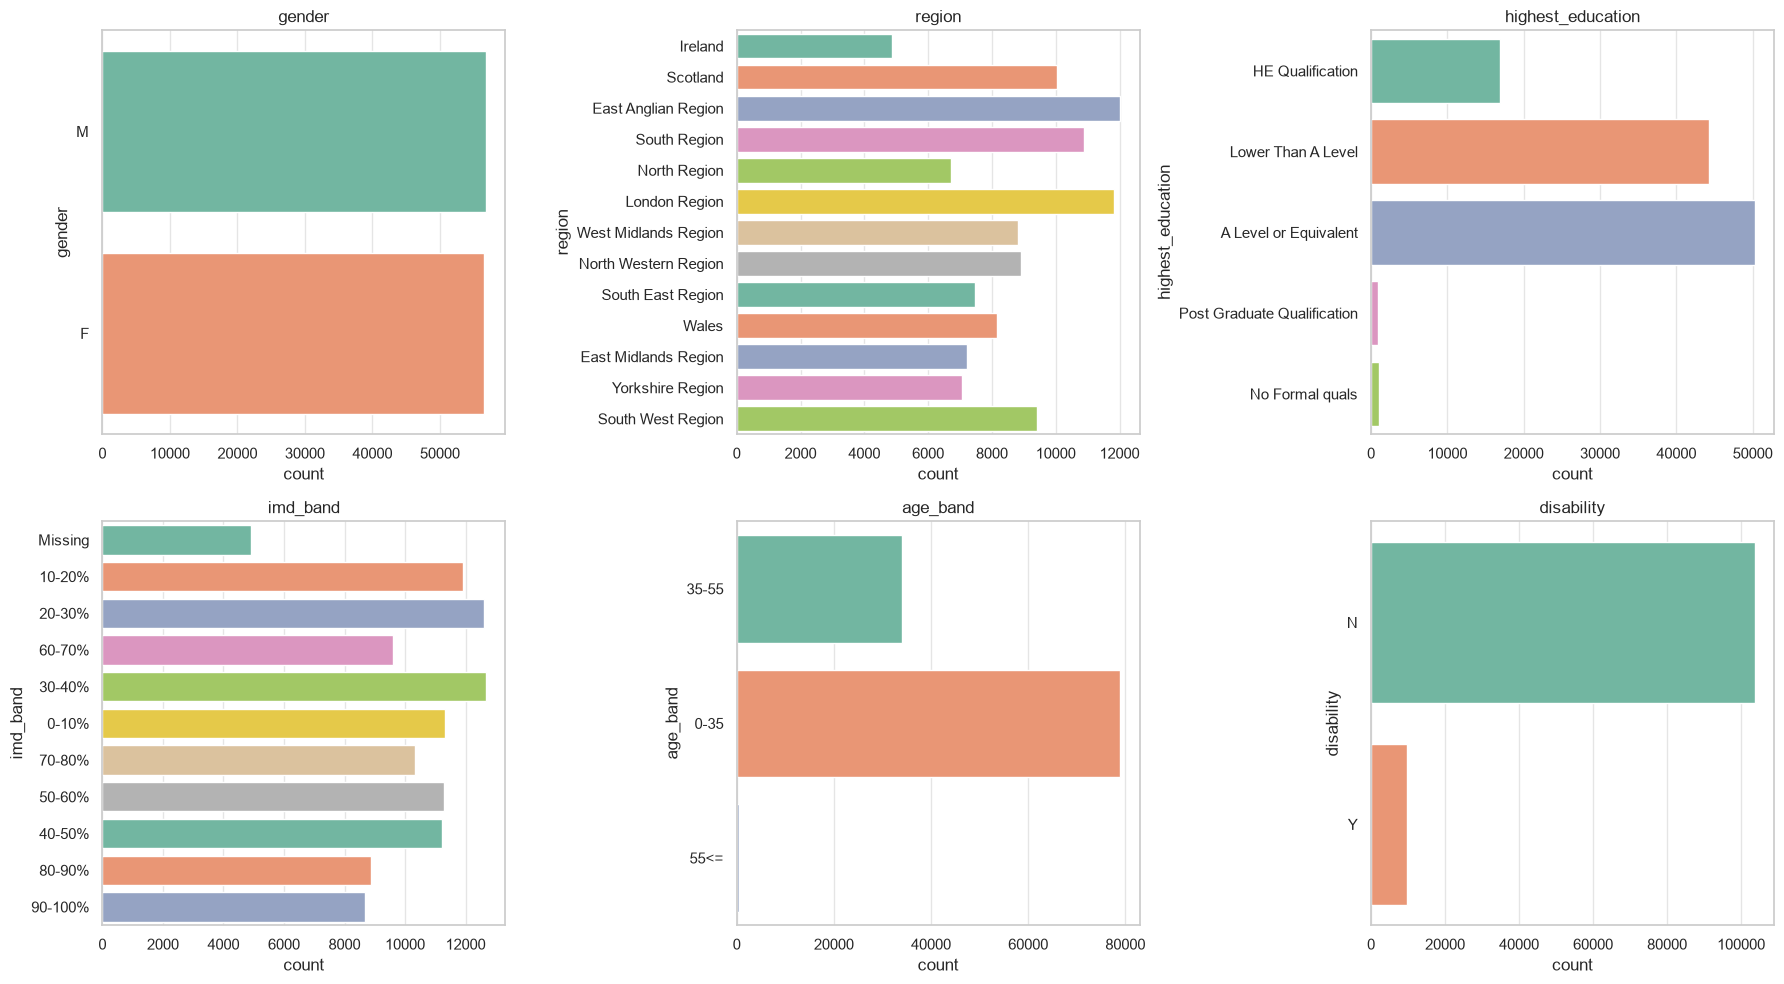

In [22]:
plot_df = train_df[categorical_features].fillna("Missing")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for column, ax in zip(categorical_features, axes.flatten()):
    sns.countplot(
        data=plot_df,
        y=column,
        hue=column,
        palette="Set2",
        legend=False,
        ax=ax,
    )
    ax.set_title(column)

plt.tight_layout()
plt.show()

=> Các cột có phân phối chưa cân bằng:

- `highest_education` tập trung nhiều ở `A Level or Equivalent` và
  `Lower Than A Level`.
- `age_band` tập trung chủ yếu ở nhóm `0–35`, còn nhóm `55<=` rất ít.
- `disability` tập trung phần lớn ở nhóm `N`.

Đây là sự chênh lệch giữa các giá trị của đặc trưng đầu vào, không phải
mất cân bằng của biến mục tiêu, nên không cần cân bằng lại dữ liệu.
--> Các category được giữ nguyên để mã hóa.

### 2.5 Phân tích phân phối numerical

Mục này không thực hiện phân tích thuộc tính `week_no` vì đây là số tuần luôn luôn có giá trị từ 2 cho tới tuần cuối cùng của môn học có chiều dài dài nhất.

In [23]:
numeric_features = [
    "num_of_prev_attempts",
    "studied_credits",
    "click_count_week",
    "click_count_to_week",
    "active_day_count_week",
    "active_day_count_to_week",
    "site_count_to_week",
    "activity_type_count_to_week",
    "coursework_due_count_to_week",
    "coursework_submitted_count_week",
    "coursework_submitted_count_to_week",
    "coursework_late_count_to_week",
    "coursework_overdue_count_to_week",
]

train_df[numeric_features].describe()

,num_of_prev_attempts,studied_credits,click_count_week,click_count_to_week,active_day_count_week,active_day_count_to_week,site_count_to_week,activity_type_count_to_week,coursework_due_count_to_week,coursework_submitted_count_week,coursework_submitted_count_to_week,coursework_late_count_to_week,coursework_overdue_count_to_week
count,113392.000000,113392.000000,113392.000000,113392.000000,113392.000000,113392.000000,113392.000000,113392.000000,113392.000000,113392.000000,113392.000000,113392.000000,113392.000000
mean,0.248536,86.260539,49.245714,1163.576628,2.147039,50.550286,70.176485,8.691036,5.891544,0.267717,5.204432,2.000309,1.208842
std,0.563347,40.125337,95.307418,1475.012602,2.195885,43.407917,56.081411,2.714157,3.878680,0.598861,3.850046,2.336955,2.503345
min,0.000000,60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,60.000000,0.000000,258.000000,0.000000,18.000000,27.000000,7.000000,3.000000,0.000000,2.000000,0.000000,0.000000
50%,0.000000,60.000000,11.000000,632.000000,2.000000,38.000000,54.000000,9.000000,5.000000,0.000000,5.000000,1.000000,0.000000
75%,0.000000,120.000000,57.000000,1501.000000,4.000000,72.000000,102.000000,11.000000,10.000000,0.000000,8.000000,3.000000,1.000000
max,5.000000,360.000000,3977.000000,20917.000000,7.000000,255.000000,413.000000,14.000000,13.000000,8.000000,13.000000,12.000000,13.000000


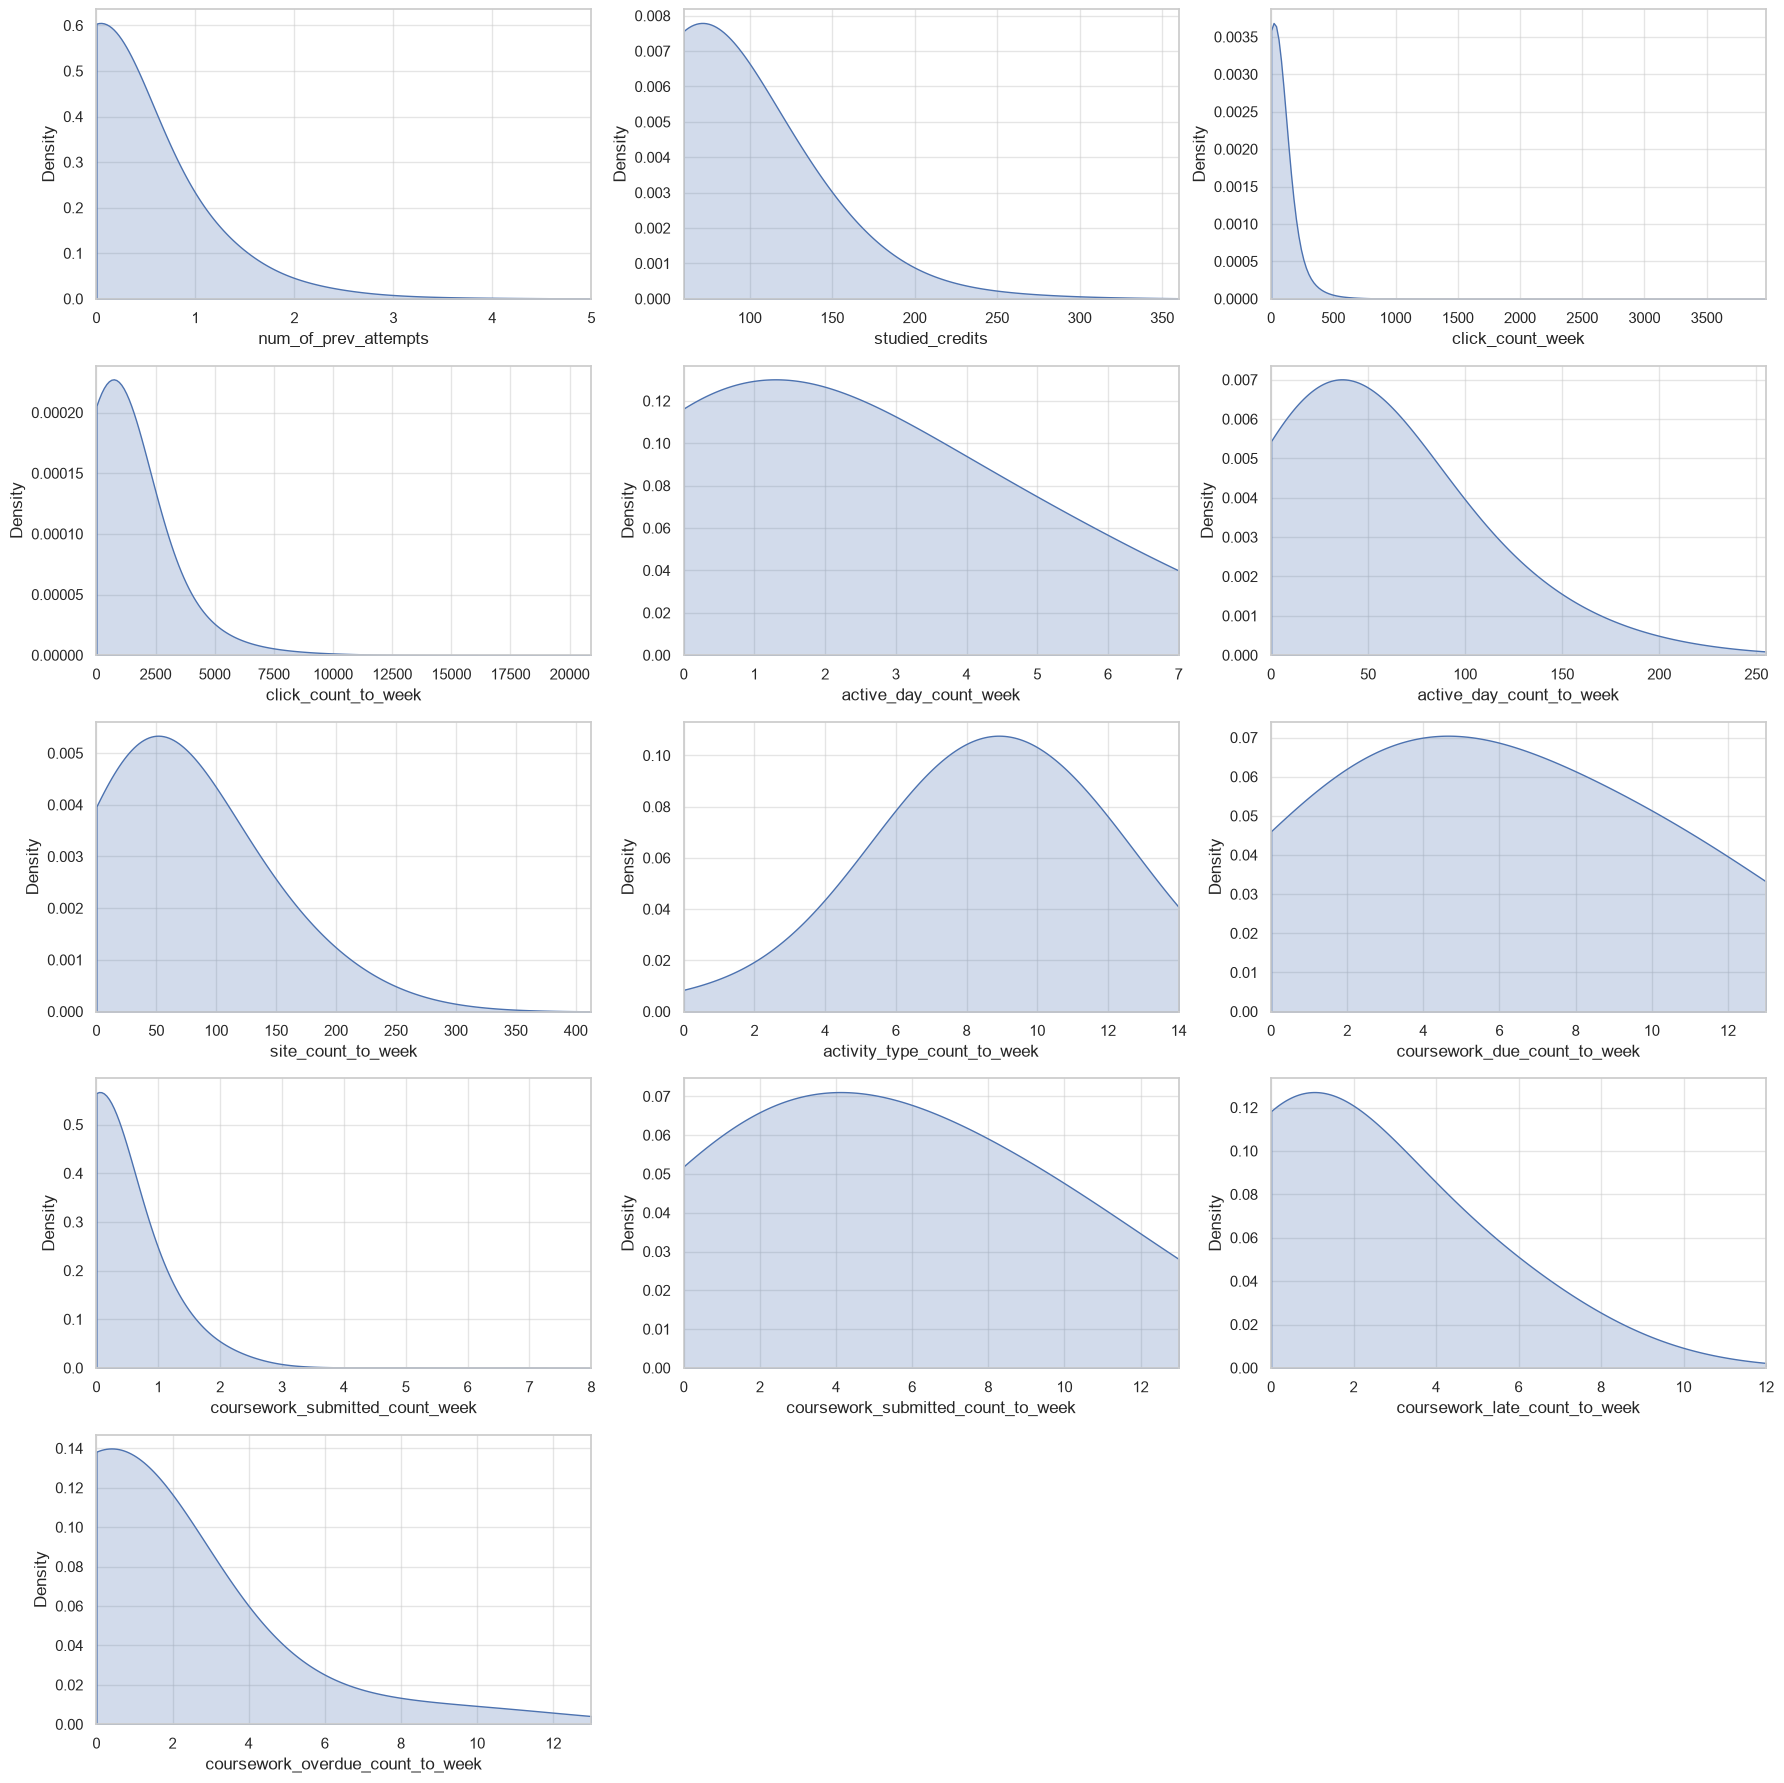

In [24]:
fig, axes = plt.subplots(5, 3, figsize=(18, 18))

for column, ax in zip(numeric_features, axes.flatten()):
    sns.kdeplot(
        data=train_df,
        x=column,
        fill=True,
        bw_adjust=10,
        cut=0,
        ax=ax
    )
    ax.margins(x=0)

for ax in axes.flat[-2:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

=> Phần lớn thuộc tính số có phân phối lệch phải, rõ nhất ở `click_count_week` và `click_count_to_week`.

- `num_of_prev_attempts` và `coursework_submitted_count_week` tập trung nhiều tại 0.
- Các thuộc tính tích lũy phân bố rộng dần theo tuần, nên giá trị lớn chưa thể xem ngay là ngoại lệ.
- Chưa xử lý hoặc loại bỏ dữ liệu ở bước này.

### 2.6 Phân tích outlier

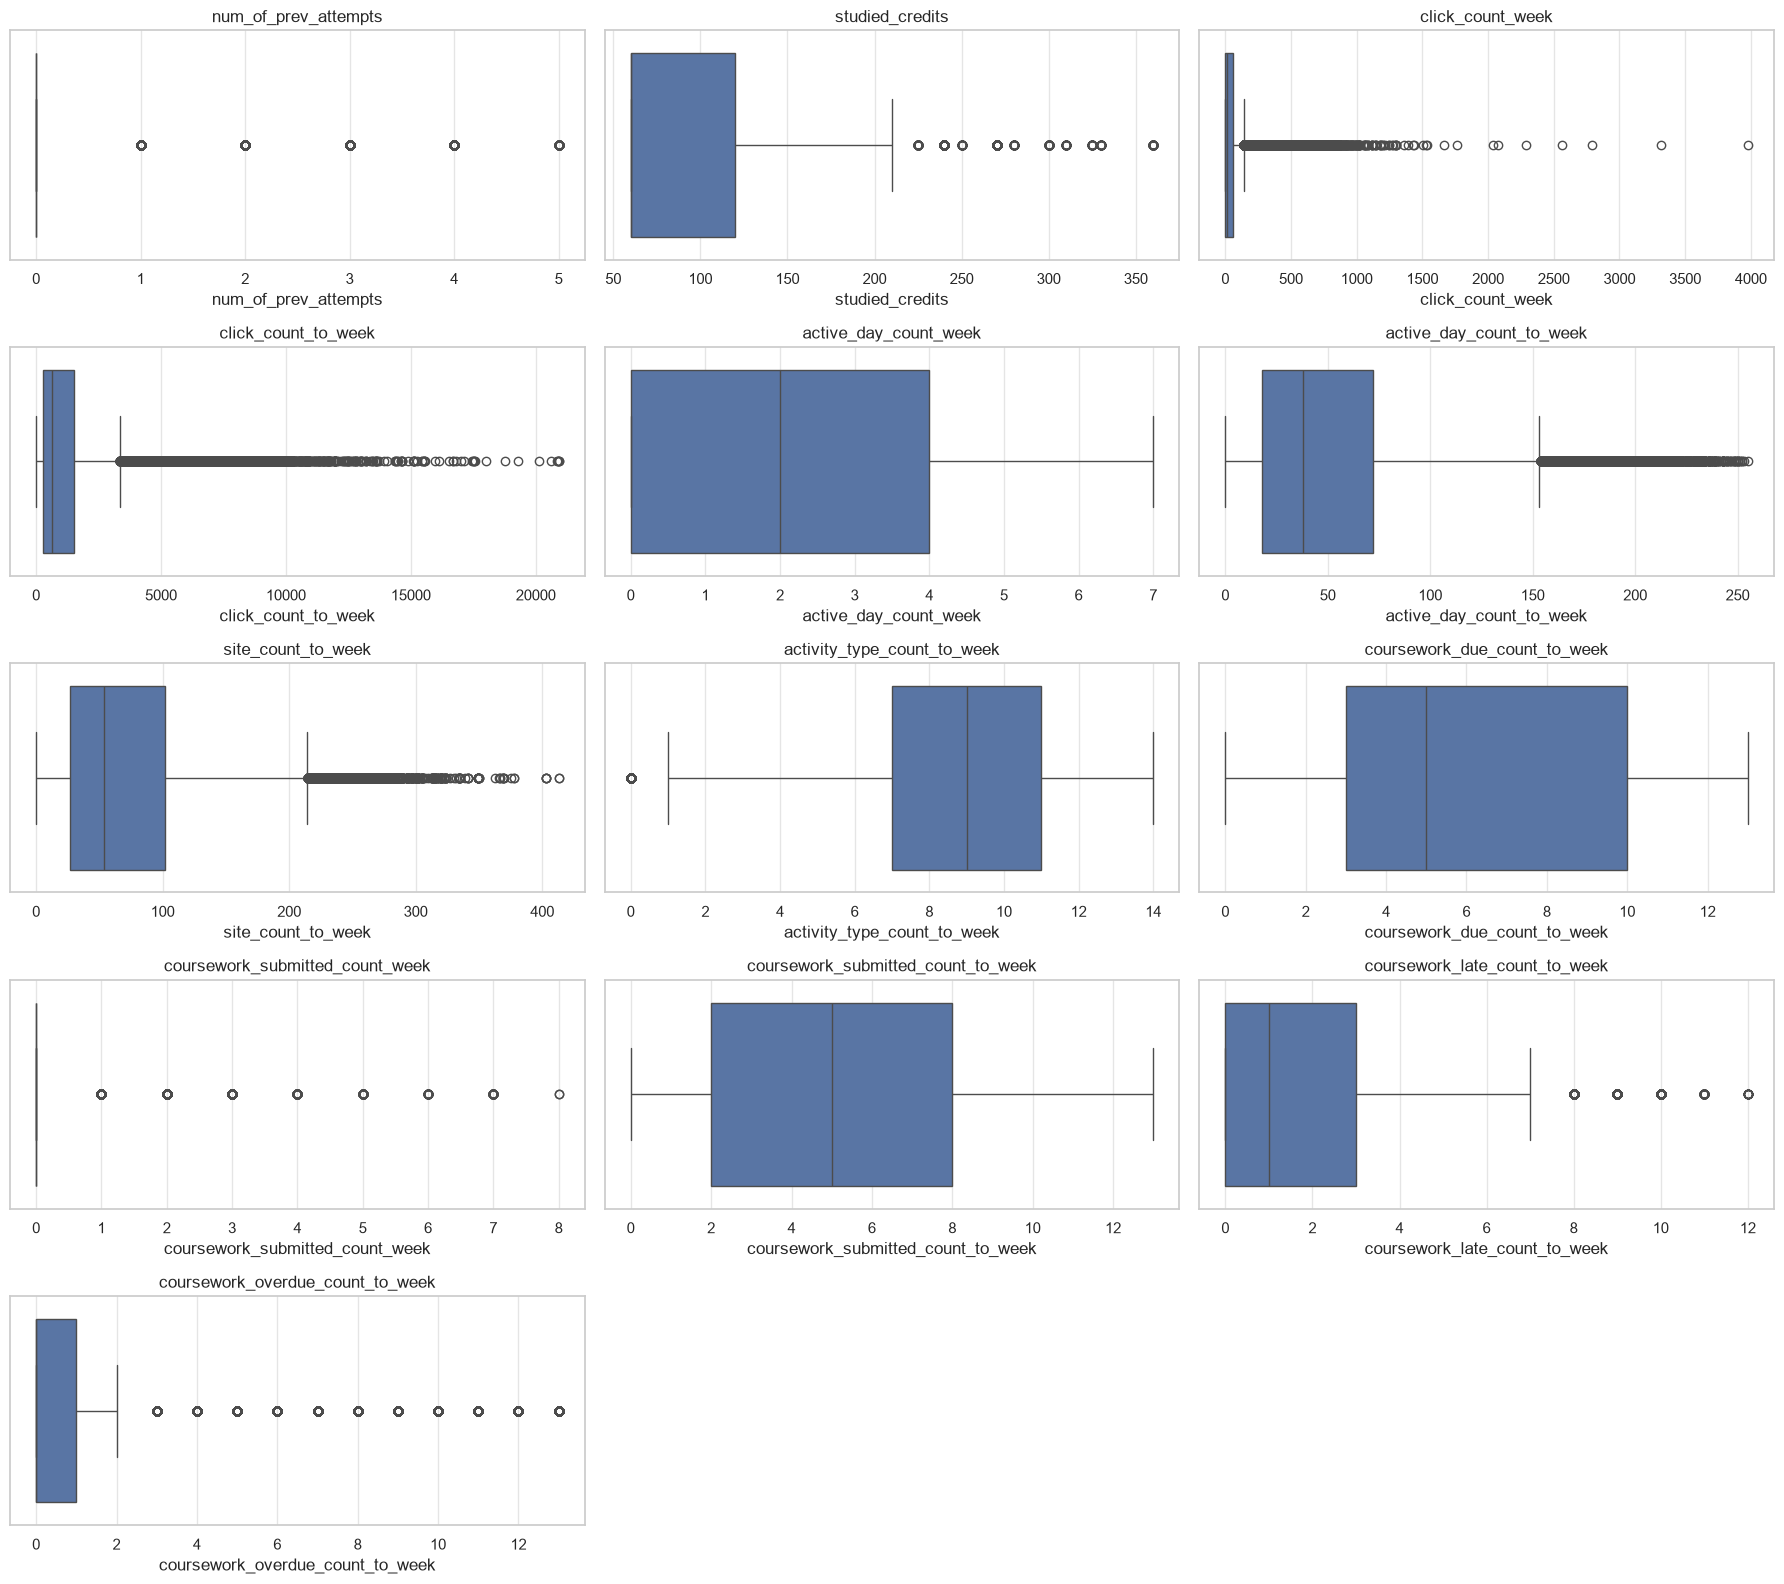

In [25]:
fig, axes = plt.subplots(5, 3, figsize=(18, 16))
axes = axes.flatten()

for column, ax in zip(numeric_features, axes):
    sns.boxplot(
        data=train_df,
        x=column,
        ax=ax,
    )
    ax.set_title(column)

for ax in axes.flat[-2:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [26]:
invalid_summary = pd.Series({
    "Giá trị số âm":
        train_df[numeric_features].lt(0).any(axis=1).sum(),

    "Tuần nhỏ hơn 2":
        (train_df["week_no"] < 2).sum(),

    "Số ngày hoạt động tuần > 7":
        (train_df["active_day_count_week"] > 7).sum(),

    "Click tuần > click tích lũy":
        (train_df["click_count_week"]
         > train_df["click_count_to_week"]).sum(),

    "Ngày hoạt động tuần > tích lũy":
        (train_df["active_day_count_week"]
         > train_df["active_day_count_to_week"]).sum(),

    "Bài nộp tuần > bài nộp tích lũy":
        (train_df["coursework_submitted_count_week"]
         > train_df["coursework_submitted_count_to_week"]).sum(),

    "Bài nộp trễ > tổng bài đã nộp":
        (train_df["coursework_late_count_to_week"]
         > train_df["coursework_submitted_count_to_week"]).sum(),

    "Bài quá hạn > tổng bài đến hạn":
        (train_df["coursework_overdue_count_to_week"]
         > train_df["coursework_due_count_to_week"]).sum(),
})

print(invalid_summary)

Giá trị số âm                      0
Tuần nhỏ hơn 2                     0
Số ngày hoạt động tuần > 7         0
Click tuần > click tích lũy        0
Ngày hoạt động tuần > tích lũy     0
Bài nộp tuần > bài nộp tích lũy    0
Bài nộp trễ > tổng bài đã nộp      0
Bài quá hạn > tổng bài đến hạn     0
dtype: int64


=> Các giá trị lớn xuất hiện trên boxplot chủ yếu do đặc điểm phân phối lệch,
dữ liệu đếm rời rạc và các thuộc tính tích lũy theo tuần. Không phát hiện
giá trị vi phạm các giới hạn nghiệp vụ cơ bản, vì vậy chưa có cơ sở xem
chúng là lỗi hoặc loại bỏ khỏi dữ liệu.

### 2.7 Phân tích tương quan

In [28]:
gender_map = {
    "F": 0,
    "M": 1
}

age_map = {
    "0-35": 0,
    "35-55": 1,
    "55<=": 2
}

highest_education_map = {
    "No Formal quals": 0,
    "Lower Than A Level": 1,
    "A Level or Equivalent": 2,
    "HE Qualification": 3,
    "Post Graduate Qualification": 4
}

imd_band_map = {
    "0-10%": 0,
    "10-20%": 1,
    "20-30%": 2,
    "30-40%": 3,
    "40-50%": 4,
    "50-60%": 5,
    "60-70%": 6,
    "70-80%": 7,
    "80-90%": 8,
    "90-100%": 9
}

disability_map = {
    "N": 0,
    "Y": 1
}

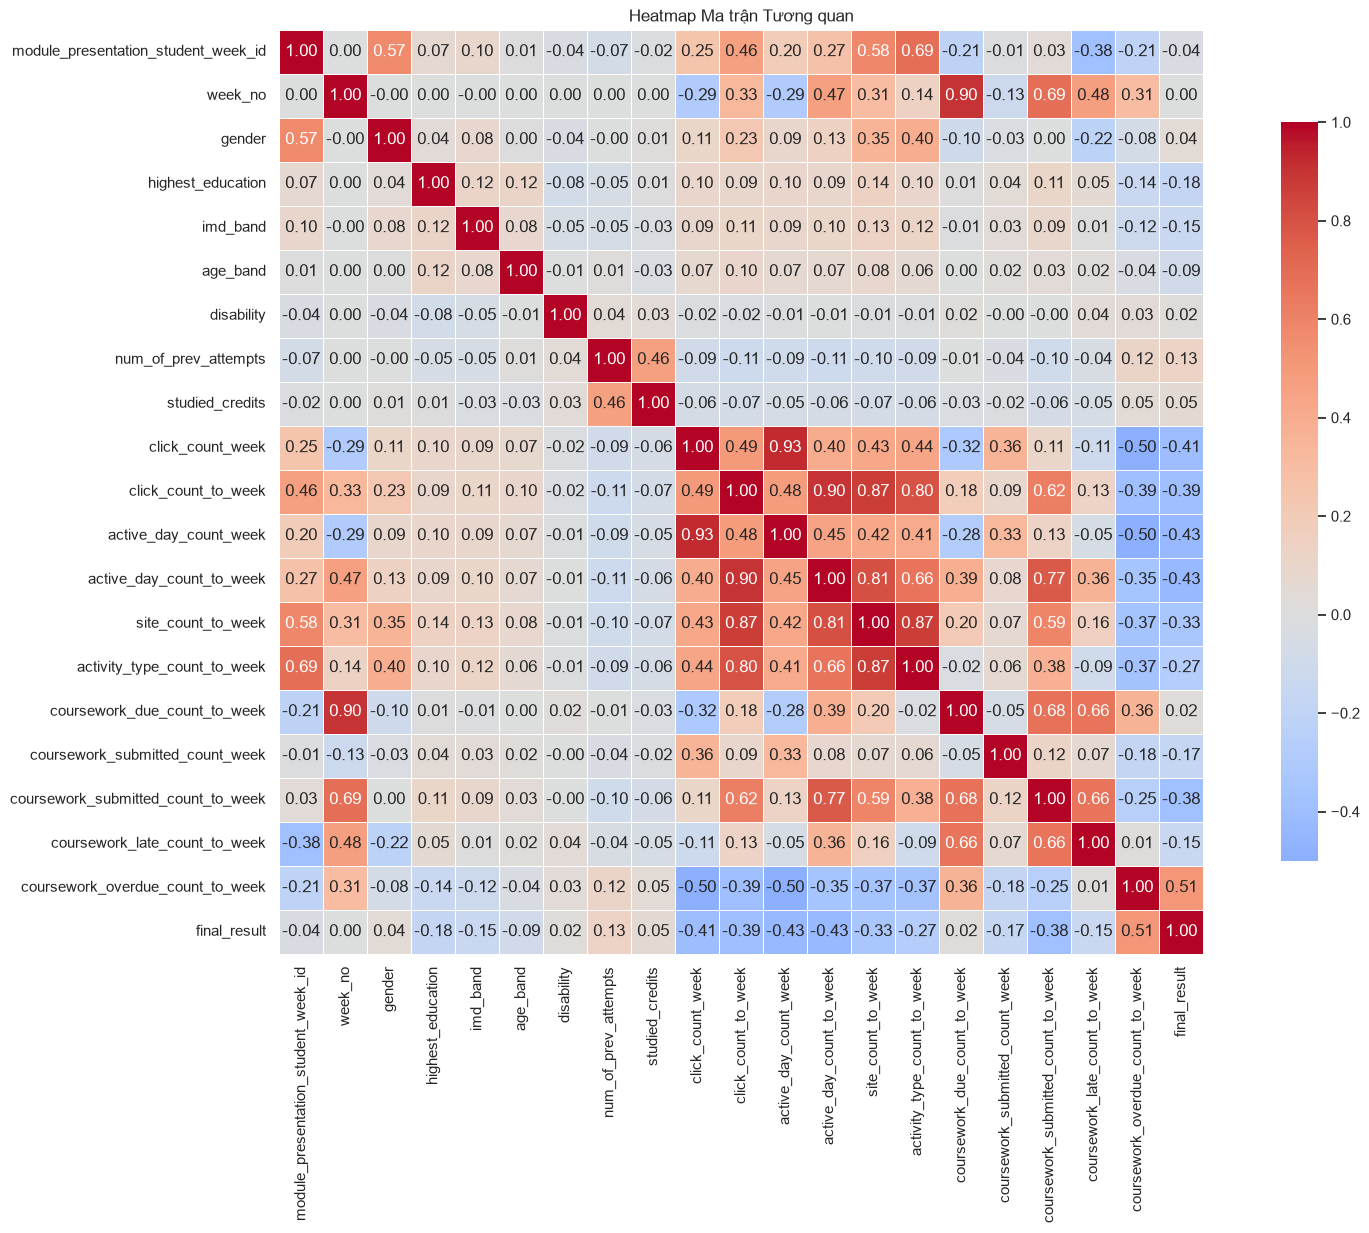

In [29]:
corr_df = train_df.drop(columns=[
    'code_module',
    'id_student',
    'code_presentation',
    'region'
])

corr_df['gender'] = corr_df['gender'].map(gender_map)
corr_df['age_band'] = corr_df['age_band'].map(age_map)
corr_df['highest_education'] = corr_df['highest_education'].map(highest_education_map)
corr_df['imd_band'] = corr_df['imd_band'].map(imd_band_map)
corr_df['disability'] = corr_df['disability'].map(disability_map)
corr_df['final_result'] = corr_df['final_result'].map(target_map)

#Spearman phù hợp hơn Pearson vì dữ liệu có nhiều biến đếm lệch phải và biến thứ tự.
corr_matrix = corr_df.corr(method="spearman")

plt.figure(figsize=(20, 12))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            fmt='.2f')

plt.title('Heatmap Ma trận Tương quan')
plt.show()

In [16]:
print("Các biến tương quan mạnh với final_result:")

final_result_corr = corr_matrix['final_result'].drop('final_result').sort_values(key=abs, ascending=False)

groups = {
    "Rất mạnh": [],
    "Mạnh": [],
    "Trung bình": [],
    "Yếu": [],
    "Rất yếu": []
}

for var, corr_val in final_result_corr.items():
    abs_val = abs(corr_val)

    if abs_val >= 0.7:
        group = "Rất mạnh"
    elif abs_val >= 0.5:
        group = "Mạnh"
    elif abs_val >= 0.3:
        group = "Trung bình"
    elif abs_val >= 0.1:
        group = "Yếu"
    else:
        group = "Rất yếu"

    groups[group].append(f"{var}: {corr_val:.2f}")

for group_name in groups.keys():
    if groups[group_name]:
        print(f"\n{group_name}:")
        for item in groups[group_name]:
            print(f"  {item}")


Các biến tương quan mạnh với final_result:

Mạnh:
  coursework_overdue_count_to_week: 0.51

Trung bình:
  active_day_count_to_week: -0.43
  active_day_count_week: -0.43
  click_count_week: -0.41
  click_count_to_week: -0.39
  coursework_submitted_count_to_week: -0.38
  site_count_to_week: -0.33

Yếu:
  activity_type_count_to_week: -0.27
  highest_education: -0.18
  coursework_submitted_count_week: -0.17
  coursework_late_count_to_week: -0.15
  imd_band: -0.15
  num_of_prev_attempts: 0.13

Rất yếu:
  age_band: -0.09
  studied_credits: 0.05
  gender: 0.04
  module_presentation_student_week_id: -0.04
  disability: 0.02
  coursework_due_count_to_week: 0.02
  week_no: 0.00


In [17]:
print("Các cặp biến tương quan mạnh với nhau (|r| >= 0.7):")

cols = corr_matrix.columns.tolist()

pairs = {
    "Rất mạnh": [],
    "Mạnh": []
}

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        col1 = cols[i]
        col2 = cols[j]

        corr_val = corr_matrix.loc[col1, col2]

        if abs(corr_val) >= 0.7:
            if abs(corr_val) >= 0.9:
                level = "Rất mạnh"
            else:
                level = "Mạnh"

            pairs[level].append(f"{col1} - {col2}: {corr_val:.2f}")

for level in pairs.keys():
    if pairs[level]:
        print(f"\n{level}:")
        for item in pairs[level]:
            print(f"  {item}")

Các cặp biến tương quan mạnh với nhau (|r| >= 0.7):

Rất mạnh:
  click_count_week - active_day_count_week: 0.93
  click_count_to_week - active_day_count_to_week: 0.90

Mạnh:
  week_no - coursework_due_count_to_week: 0.90
  click_count_to_week - site_count_to_week: 0.87
  click_count_to_week - activity_type_count_to_week: 0.80
  active_day_count_to_week - site_count_to_week: 0.81
  active_day_count_to_week - coursework_submitted_count_to_week: 0.77
  site_count_to_week - activity_type_count_to_week: 0.87


Các biến tương quan đáng chú ý với `final_result`:

- `coursework_overdue_count_to_week` tương quan dương mạnh nhất (0.51), cho thấy sinh viên có nhiều bài quá hạn thường có nguy cơ `Fail` cao hơn.
- Các biến về số click, số ngày hoạt động và số bài đã nộp có tương quan âm, tức là sinh viên hoạt động và nộp bài nhiều hơn thường ít có nguy cơ `Fail`.
- Các biến nhân khẩu học như `gender`, `age_band`, `disability` có tương quan khá thấp với kết quả.

Một số cặp biến có tương quan cao do cùng phản ánh hoạt động học tập hoặc đều được cộng dồn theo tuần.

=> Chưa loại bỏ các biến tương quan cao vì chúng vẫn có ý nghĩa khác nhau.

### 2.8 Kết luận EDA

Qua quá trình EDA trên tập huấn luyện `2013B`:

- Tập dữ liệu có 113.392 dòng và 25 cột. Các kiểm tra cơ bản không phát hiện dòng trùng, giá trị âm hoặc giá trị tuần lớn hơn giá trị tích lũy.
- Lớp `Fail` chiếm 37%, còn `Pass + Distinction` chiếm 63%. Dữ liệu mất cân bằng ở mức vừa phải nên chưa cần cân bằng lại ngay.
- Chỉ có `imd_band` bị thiếu 4%. Giá trị này sẽ được xử lý bằng cách tạo thêm cờ missing trong bước tiền xử lý.
- Một số biến categorical có phân phối chênh lệch, nhưng đây không phải mất cân bằng của target nên không cần xử lý cân bằng.
- Phần lớn biến số có phân phối lệch phải, đặc biệt là các biến click. Tuy nhiên không phát hiện giá trị vi phạm quy tắc nghiệp vụ nên chưa loại bỏ outlier.
- `coursework_overdue_count_to_week` có tương quan dương rõ nhất với `Fail`. Ngược lại, số click, ngày hoạt động và số bài đã nộp có tương quan âm với `Fail`.
- Một số biến hành vi tương quan mạnh với nhau do cùng phản ánh hoạt động học tập hoặc cùng được tích lũy theo tuần. Trước mắt vẫn giữ lại vì chúng có ý nghĩa khác nhau.

=> Dữ liệu `2013B` có thể chuyển sang bước tiền xử lý. Việc cân bằng lớp, loại bớt đặc trưng hoặc biến đổi dữ liệu chỉ được quyết định dựa trên kết quả của tập validation `2013J`.

## 3. Preprocessing

### 3.1 Feature Engineering

Ba đặc trưng được tính riêng trong từng presentation và chỉ sử dụng dữ liệu
từ tuần hiện tại trở về trước:

- `click_delta_1w`: thay đổi số click so với tuần trước.
- `inactive_streak_weeks`: số tuần không hoạt động liên tiếp tính đến tuần hiện tại.
- `coursework_overdue_rate`: tỷ lệ coursework quá hạn trên số coursework đã đến hạn.

In [30]:
ENGINEERED_FEATURES = [
    "click_delta_1w",
    "inactive_streak_weeks",
    "coursework_overdue_rate",
]

GROUP_COLUMNS = [
    "id_student",
    "code_module",
    "code_presentation",
]


def build_features(frame):
    required_columns = GROUP_COLUMNS + [
        "week_no",
        "click_count_week",
        "coursework_due_count_to_week",
        "coursework_overdue_count_to_week"
    ]

    missing_columns = sorted(set(required_columns) - set(frame.columns))
    if missing_columns:
        raise ValueError(f"Thiếu cột để tạo feature: {missing_columns}")

    result = frame.copy()
    result["__row_order"] = np.arange(len(result))

    result = result.sort_values(
        GROUP_COLUMNS + ["week_no"]
    )

    grouped_clicks = result.groupby(
        GROUP_COLUMNS,
        sort=False,
    )["click_count_week"]

    result["click_delta_1w"] = (
        grouped_clicks.diff().fillna(0.0)
    )

    inactive = result["click_count_week"].eq(0)
    groupers = [result[column] for column in GROUP_COLUMNS]

    activity_block = (
        (~inactive)
        .groupby(groupers, sort=False)
        .cumsum()
    )

    result["inactive_streak_weeks"] = (
        inactive.astype(int)
        .groupby(groupers + [activity_block], sort=False)
        .cumsum()
    )

    due_count = result["coursework_due_count_to_week"]

    result["coursework_overdue_rate"] = (
        result["coursework_overdue_count_to_week"]
        .div(due_count)
        .where(due_count.gt(0), 0.0)
    )

    result = (
        result.sort_values("__row_order")
        .drop(columns="__row_order")
    )

    if not np.isfinite(
        result[ENGINEERED_FEATURES].to_numpy(dtype=float)
    ).all():
        raise ValueError("Feature Engineering tạo ra NaN hoặc giá trị vô hạn")

    return result

### 3.2 Tách feature và target


In [31]:
drop_columns = [
    "module_presentation_student_week_id",
    "id_student",
    "code_module",
    "code_presentation",
    "final_result",
]

X_train = train_df.drop(columns=drop_columns)
X_val = val_df.drop(columns=drop_columns)

y_train = train_df["final_result"].map(target_map)
y_val = val_df["final_result"].map(target_map)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:", X_val.shape, "| y_val:", y_val.shape)

X_train: (113392, 20) | y_train: (113392,)
X_val: (243600, 20) | y_val: (243600,)


### 3.3 Phân nhóm feature theo cách xử lý

In [32]:
categorical_features = [
    "gender",
    "region",
    "disability",
]

ordinal_features = [
    "highest_education",
    "imd_band",
    "age_band",
]

numeric_features = X_train.select_dtypes(include="number").columns.tolist()

print("Nominal:", len(categorical_features))
print("Ordinal:", len(ordinal_features))
print("Numeric:", len(numeric_features))

Nominal: 3
Ordinal: 3
Numeric: 14


### 3.4 Lựa chọn phương pháp tiền xử lý

- `gender`, `region` và `disability` là các biến không có thứ tự nên sử dụng
  One-Hot Encoding. Các giá trị mới xuất hiện ở dữ liệu sau sẽ được bỏ qua
  để tránh lỗi khi dự báo.

- `highest_education`, `age_band` và `imd_band` có thứ tự nên được mã hóa
  theo đúng thứ tự giữa các nhóm, không sử dụng One-Hot Encoding.

- Riêng `imd_band` có 4% giá trị thiếu. Giá trị thiếu sẽ được điền bằng mức
  trung bình tính từ tập train và tạo thêm một cột đánh dấu missing. Không
  gán missing thành mức 10 vì cách đó sẽ khiến mô hình hiểu missing cao hơn
  nhóm `90-100%`.

- Các biến số sử dụng StandardScaler để đưa về thang đo tương đương trước
  khi huấn luyện Logistic Regression. StandardScaler không được dùng để xử
  lý phân phối lệch hoặc outlier.

- Chưa cân bằng lớp và chưa loại bỏ các biến tương quan cao. Các lựa chọn
  này sẽ được đánh giá bằng kết quả trên tập validation `2013J`.

### 3.5 Xây dựng bộ tiền xử lý

In [33]:
ordinal_features = [
    "highest_education",
    "imd_band",
    "age_band",
]

ordinal_categories = [
    [
        "No Formal quals",
        "Lower Than A Level",
        "A Level or Equivalent",
        "HE Qualification",
        "Post Graduate Qualification",
    ],
    [
        "0-10%",
        "10-20%",
        "20-30%",
        "30-40%",
        "40-50%",
        "50-60%",
        "60-70%",
        "70-80%",
        "80-90%",
        "90-100%",
    ],
    [
        "0-35",
        "35-55",
        "55<=",
    ],
]

ordinal_pipeline = Pipeline([
    (
        "encoder",
        OrdinalEncoder(
            categories=ordinal_categories,
            handle_unknown="use_encoded_value",
            unknown_value=np.nan,
        ),
    ),
    (
        "imputer",
        SimpleImputer(
            strategy="mean",
            add_indicator=True, # xử lý thêm cờ missing cho imd_band
        ),
    ),
])

preprocessor = ColumnTransformer([
    (
        "categorical",
        OneHotEncoder(
            handle_unknown="ignore",
            drop="if_binary",
            sparse_output=False,
        ),
        categorical_features,
    ),
    (
        "ordinal",
        ordinal_pipeline,
        ordinal_features,
    ),
    (
        "numeric",
        StandardScaler(),
        numeric_features,
    ),
])

print(preprocessor)

ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(drop='if_binary',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['gender', 'region', 'disability']),
                                ('ordinal',
                                 Pipeline(steps=[('encoder',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'Formal '
                                                                              'quals',
                                                                              'Lower '
                                                                              'Than '
                                                                              'A '
                                                        

### 3.6 Kiểm tra kết quả tiền xử lý

In [34]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

feature_names = preprocessor.get_feature_names_out()

print("Train trước xử lý:", X_train.shape)
print("Train sau xử lý:", X_train_processed.shape)

print("Validation trước xử lý:", X_val.shape)
print("Validation sau xử lý:", X_val_processed.shape)

print("Số giá trị NaN train:", np.isnan(X_train_processed).sum())
print("Số giá trị NaN validation:", np.isnan(X_val_processed).sum())

print("Cột missing được tạo:")
print([name for name in feature_names if "missing" in name])

Train trước xử lý: (113392, 20)
Train sau xử lý: (113392, 33)
Validation trước xử lý: (243600, 20)
Validation sau xử lý: (243600, 33)
Số giá trị NaN train: 0
Số giá trị NaN validation: 0
Cột missing được tạo:
['ordinal__missingindicator_imd_band']


## 4. Huấn luyện và tinh chỉnh mô hình

### 4.1 Các hàm dùng chung

Hàm log metrics lên wandb

In [35]:
def init_run(model):
    run = wandb.init(
        entity="phat-05",
        project="learning-analytics-pipeline",
        name=model,
        config={
            "model": model
        },
    )
    return run

def log_wandb(model, result, y_true, y_pred, y_prob, cal):
    with init_run(model) as run:
        run.log({
            **result,
            "confusion_matrix": wandb.plot.confusion_matrix(
                y_true=y_true,
                preds=y_pred,
                class_names=["Not Fail", "Fail"],
            ),
            "pr_curve": wandb.plot.pr_curve(
                y_true,
                np.c_[1 - y_prob, y_prob],
                labels=["Not Fail", "Fail"],
                classes_to_plot=[1],
            ),
            "calibration_curve": wandb.plot.line(
                wandb.Table(
                    data=np.c_[cal.prob_pred, cal.prob_true],
                    columns=["predicted", "observed"],
                ),
                "predicted",
                "observed",
            ),
        })

Hàm đánh giá mô hình

In [36]:
def evaluate_model(y_true, y_prob, model_name, threshold=THRESHOLD):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    if len(y_true) != len(y_prob):
        raise ValueError("y_true và y_prob phải có cùng số phần tử")

    if not np.isin(y_true, [0, 1]).all():
        raise ValueError("y_true chỉ được chứa nhãn 0 và 1")

    if not 0 <= threshold <= 1:
        raise ValueError("threshold phải nằm trong khoảng [0, 1]")

    if ((y_prob < 0) | (y_prob > 1)).any():
        raise ValueError("y_prob phải là xác suất hợp lệ trong khoảng [0, 1]")

    y_pred = (y_prob >= threshold).astype(int)

    result = {
        "threshold": threshold,
        "recall_fail": recall_score( y_true, y_pred, pos_label=1, zero_division=0),
        "precision_fail": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_fail": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f2_fail": fbeta_score(y_true, y_pred, beta=2, pos_label=1,zero_division=0),
        "average_precision": average_precision_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "brier_score": brier_score_loss(y_true, y_prob)
    }

    print("========", model_name, "========")
    table_data = [[k, f"{v:.4f}" if isinstance(v, float) else v] for k, v in result.items()]
    print(tabulate(table_data, headers=["Metric", "Value"], tablefmt="github"))

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=["Not Fail", "Fail"],
        cmap="Blues",
        colorbar=False,
        ax=axes[0],
    )
    axes[0].set_title("Ma trận nhầm lẫn")

    PrecisionRecallDisplay.from_predictions(
        y_true,
        y_prob,
        ax=axes[1],
    )
    axes[1].set_title("Đường cong Precision–Recall")

    cal = CalibrationDisplay.from_predictions(
        y_true,
        y_prob,
        n_bins=10,
        strategy="quantile",
        ax=axes[2],
    )
    axes[2].set_title("Biểu đồ hiệu chỉnh xác suất")

    plt.tight_layout()
    plt.show()

    #log_wandb(model_name, result, y_true, y_pred, y_prob, cal)

    return result

### 4.2 Khảo sát Feature Engineering

Tạo 2 tập mới có thêm 3 cột features mới để so sánh

In [38]:
fe_train_df = build_features(train_df)
fe_val_df = build_features(val_df)

X_train_fe = fe_train_df.drop(columns=drop_columns)
X_val_fe = fe_val_df.drop(columns=drop_columns)

print("Không FE:", X_train.shape, X_val.shape)
print("Có FE:", X_train_fe.shape, X_val_fe.shape)

Không FE: (113392, 20) (243600, 20)
Có FE: (113392, 23) (243600, 23)


Tạo preprocessor riêng cho trường hợp có 3 features mới

In [39]:
fe_numeric_features = numeric_features + ENGINEERED_FEATURES

fe_preprocessor = ColumnTransformer([
    (
        "categorical",
        OneHotEncoder(
            handle_unknown="ignore",
            drop="if_binary",
            sparse_output=False,
        ),
        categorical_features,
    ),
    (
        "ordinal",
        clone(ordinal_pipeline),
        ordinal_features,
    ),
    (
        "numeric",
        StandardScaler(),
        fe_numeric_features,
    ),
])

So sánh 2 trường hợp

======== LogisticRegression : 20 features ========
| Metric            |   Value |
|-------------------|---------|
| threshold         |  0.5    |
| recall_fail       |  0.6814 |
| precision_fail    |  0.7203 |
| f1_fail           |  0.7003 |
| f2_fail           |  0.6888 |
| average_precision |  0.8067 |
| accuracy          |  0.8204 |
| brier_score       |  0.1305 |


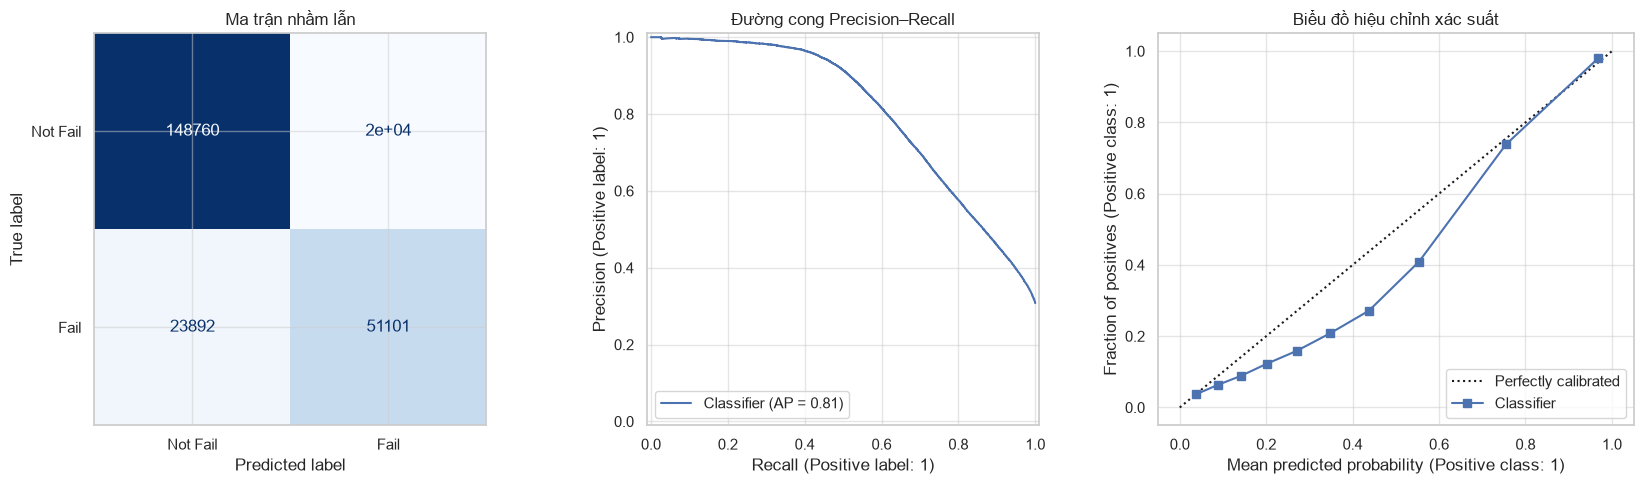

======== LogisticRegression : 20 features + 3 FE ========
| Metric            |   Value |
|-------------------|---------|
| threshold         |  0.5    |
| recall_fail       |  0.6525 |
| precision_fail    |  0.7779 |
| f1_fail           |  0.7097 |
| f2_fail           |  0.6742 |
| average_precision |  0.8214 |
| accuracy          |  0.8357 |
| brier_score       |  0.1215 |


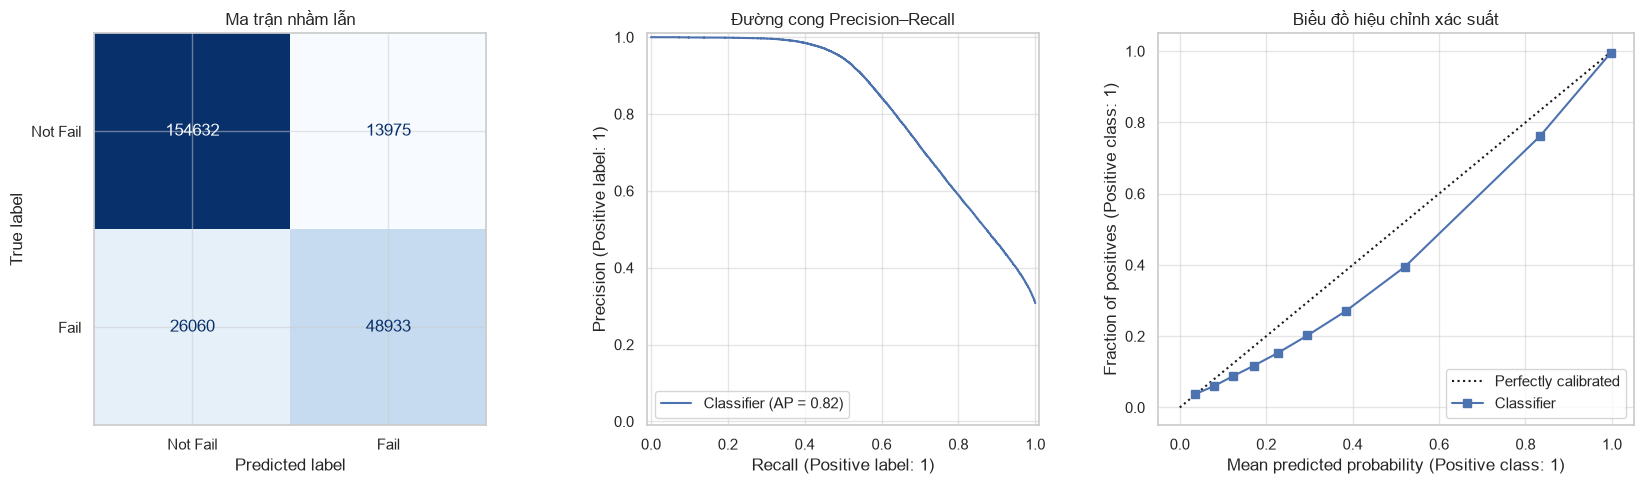

,feature_set,threshold,recall_fail,precision_fail,f1_fail,f2_fail,average_precision,accuracy,brier_score
0,20 features,0.5,0.6814,0.7203,0.7003,0.6888,0.8067,0.8204,0.1305
1,20 features + 3 FE,0.5,0.6525,0.7779,0.7097,0.6742,0.8214,0.8357,0.1215


In [40]:
lr_baseline = Pipeline([
    ("preprocessor", clone(preprocessor)),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
        ),
    ),
])

lr_with_fe = Pipeline([
    ("preprocessor", clone(fe_preprocessor)),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
        ),
    ),
])

lr_baseline.fit(X_train, y_train)
baseline_prob = lr_baseline.predict_proba(X_val)[:, 1]

lr_with_fe.fit(X_train_fe, y_train)
fe_prob = lr_with_fe.predict_proba(X_val_fe)[:, 1]

baseline_result = evaluate_model(
    y_val,
    baseline_prob,
    "LogisticRegression : 20 features",
)

fe_result = evaluate_model(
    y_val,
    fe_prob,
    "LogisticRegression : 20 features + 3 FE",
)

feature_comparison = pd.DataFrame([
    {
        "feature_set": "20 features",
        **baseline_result,
    },
    {
        "feature_set": "20 features + 3 FE",
        **fe_result,
    },
])

display(feature_comparison.round(4))

Việc bổ sung ba đặc trưng dẫn xuất giúp cải thiện Precision, Average Precision và Brier score, nhưng làm Recall và F2 giảm. Do đề tài ưu tiên hạn chế bỏ sót sinh viên Fail, mức cải thiện ở các chỉ số bổ sung chưa đủ để bù cho sự suy giảm Recall. Vì vậy, bộ 20 đặc trưng ban đầu được giữ lại để tiếp tục so sánh các mô hình.

### 4.3 Mô hình baseline

#### DummyClassifier

======== DummyClassifier ========
| Metric            |   Value |
|-------------------|---------|
| threshold         |  0.5    |
| recall_fail       |  0      |
| precision_fail    |  0      |
| f1_fail           |  0      |
| f2_fail           |  0      |
| average_precision |  0.3079 |
| accuracy          |  0.6921 |
| brier_score       |  0.3079 |


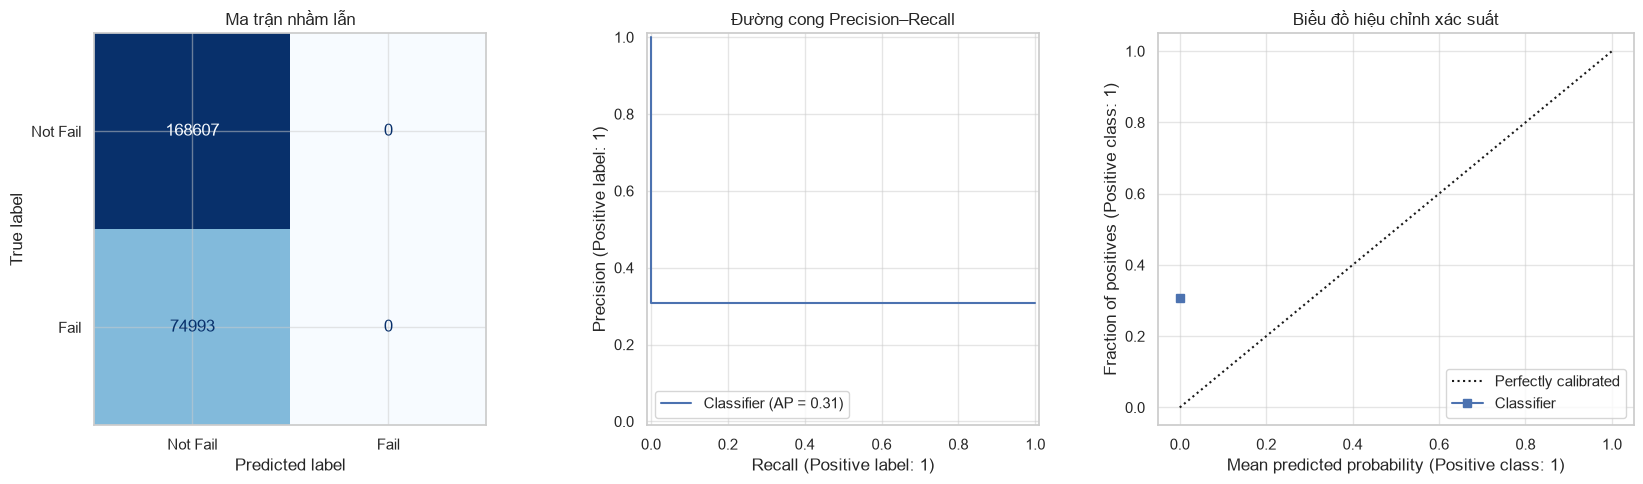

In [45]:
dummy_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", DummyClassifier(strategy="most_frequent"))
])

dummy_model.fit(X_train, y_train)

y_prob = dummy_model.predict_proba(X_val)[:, 1]

dummy_result = evaluate_model(y_val, y_prob, "DummyClassifier")

#### LogisticRegression cở sở

======== Basic LogisticRegression ========
| Metric            |   Value |
|-------------------|---------|
| threshold         |  0.5    |
| recall_fail       |  0.2515 |
| precision_fail    |  0.512  |
| f1_fail           |  0.3373 |
| f2_fail           |  0.28   |
| average_precision |  0.4613 |
| accuracy          |  0.6958 |
| brier_score       |  0.2027 |


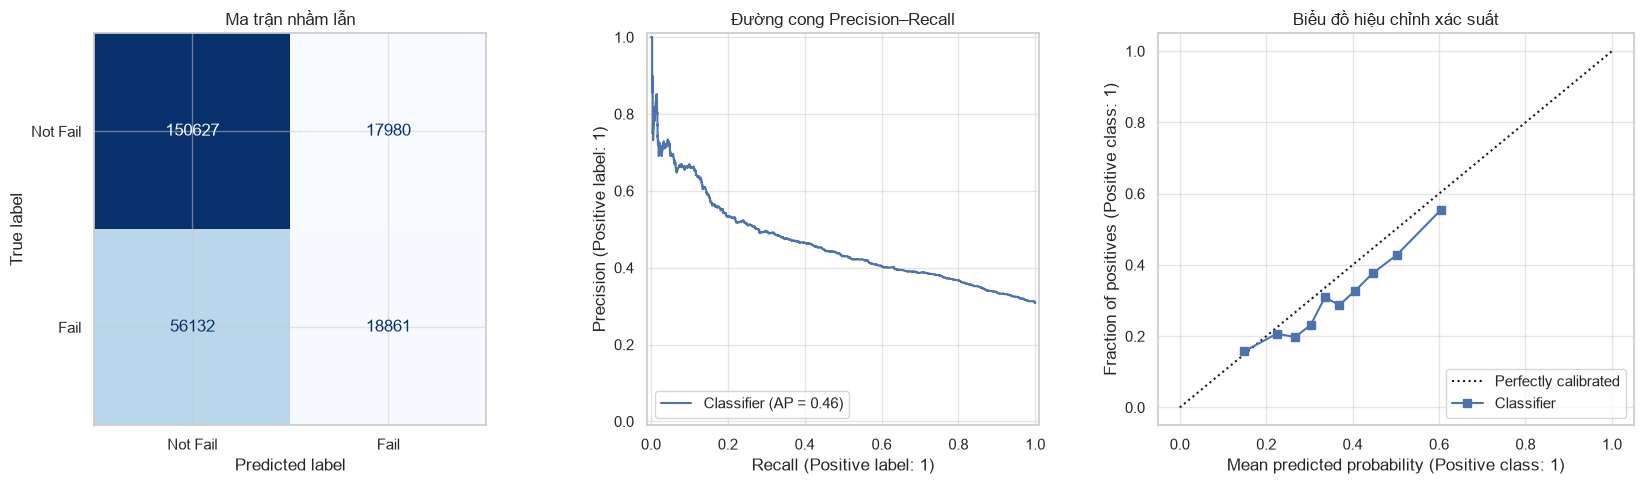

In [46]:
basic_features = [
    "week_no",
    "gender",
    "region",
    "highest_education",
    "imd_band",
    "age_band",
    "disability",
    "num_of_prev_attempts",
    "studied_credits",
]

basic_preprocessor = ColumnTransformer([
    (name, clone(transformer), [c for c in columns if c in basic_features])
    for name, transformer, columns in preprocessor.transformers
])

logistic_basic = Pipeline([
    ("preprocessor", basic_preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

logistic_basic.fit(X_train[basic_features], y_train)

y_prob = logistic_basic.predict_proba(X_val[basic_features])[:, 1]

logistic_basic_result = evaluate_model(y_val, y_prob, "Basic LogisticRegression")

#### LogisticRegression với toàn bộ đặc trưng

========  LogisticRegression ========
| Metric            |   Value |
|-------------------|---------|
| threshold         |  0.5    |
| recall_fail       |  0.6814 |
| precision_fail    |  0.7203 |
| f1_fail           |  0.7003 |
| f2_fail           |  0.6888 |
| average_precision |  0.8067 |
| accuracy          |  0.8204 |
| brier_score       |  0.1305 |


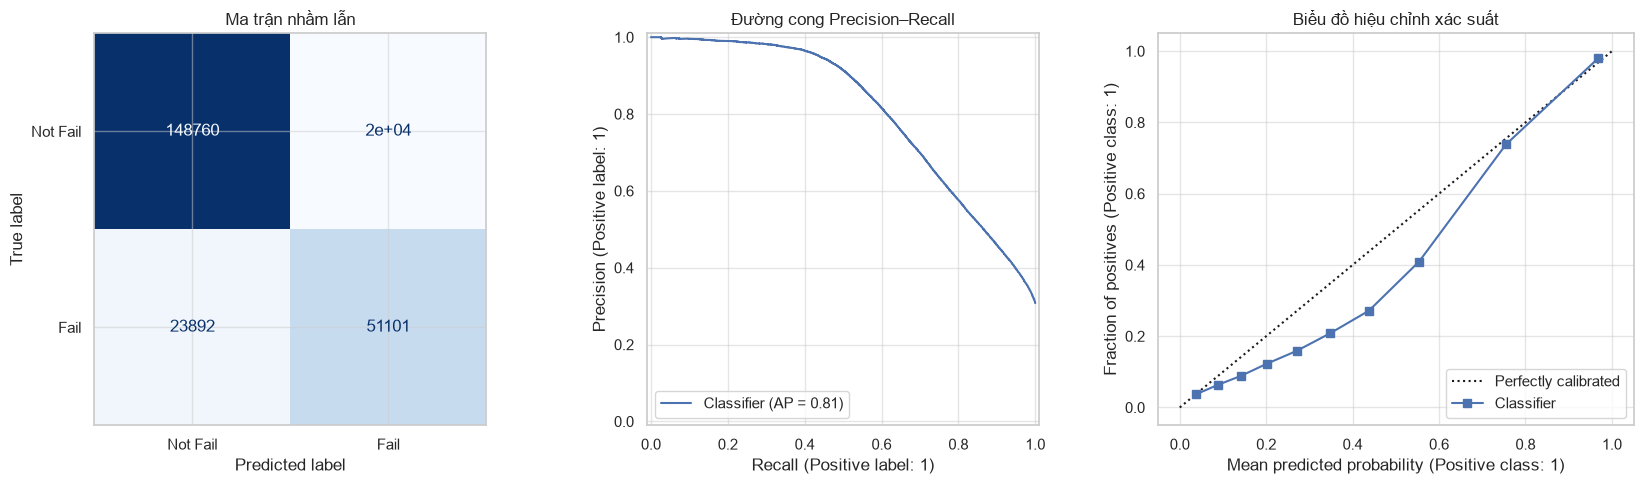

In [47]:
logistic_full = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

logistic_full.fit(X_train, y_train)

y_prob = logistic_full.predict_proba(X_val)[:, 1]

logistic_full_result = evaluate_model(y_val, y_prob, " LogisticRegression")

Logistic Regression với đầy đủ đặc trưng đạt AP 0.8067. Tại ngưỡng 0.5, mô hình phát hiện được 68.14% trường hợp Fail, đồng thời duy trì Precision 72.03% và F2 0.6888. Kết quả này cải thiện rõ rệt so với mô hình chỉ sử dụng đặc trưng cơ sở, cho thấy các đặc trưng hành vi học tập đóng góp nhiều thông tin cho dự báo.

#### RandomForest

======== RandomForest ========
| Metric            |   Value |
|-------------------|---------|
| threshold         |  0.5    |
| recall_fail       |  0.671  |
| precision_fail    |  0.7237 |
| f1_fail           |  0.6963 |
| f2_fail           |  0.6809 |
| average_precision |  0.8006 |
| accuracy          |  0.8198 |
| brier_score       |  0.133  |


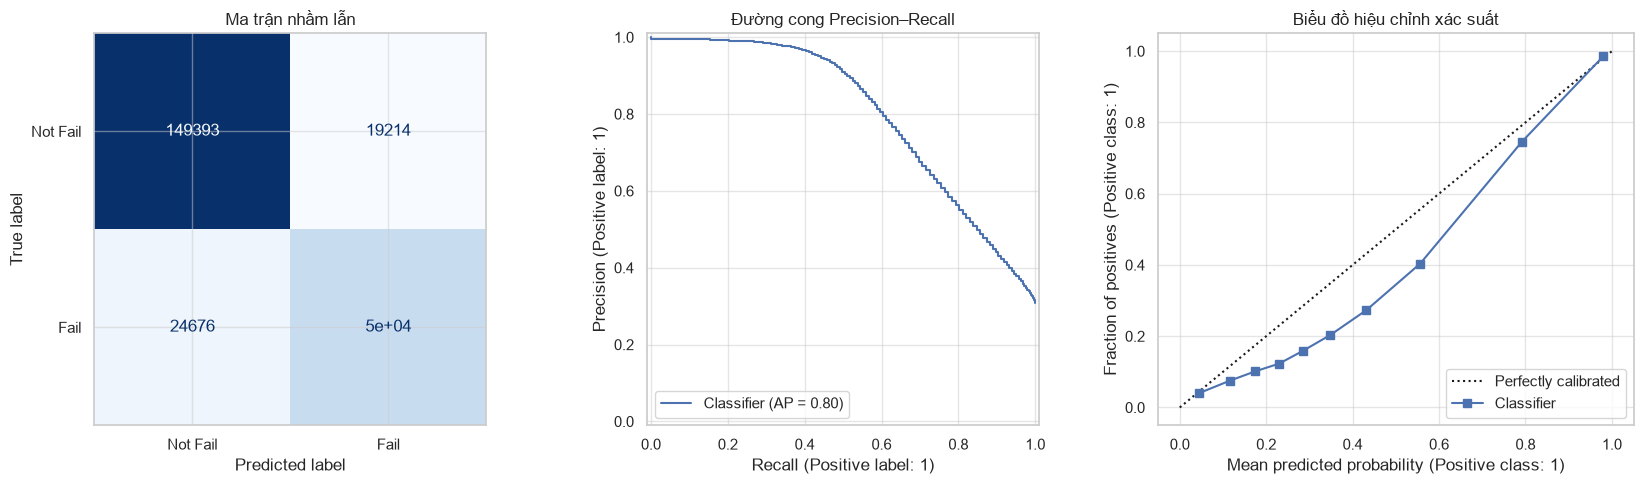

In [48]:
random_forest = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

random_forest.fit(X_train, y_train)

y_prob = random_forest.predict_proba(X_val)[:, 1]

random_forest_result = evaluate_model(
    y_val,
    y_prob,
    "RandomForest",
)

#### HistGradientBoosting

======== HistGradientBoosting ========
| Metric            |   Value |
|-------------------|---------|
| threshold         |  0.5    |
| recall_fail       |  0.6766 |
| precision_fail    |  0.7275 |
| f1_fail           |  0.7011 |
| f2_fail           |  0.6862 |
| average_precision |  0.8128 |
| accuracy          |  0.8224 |
| brier_score       |  0.1272 |


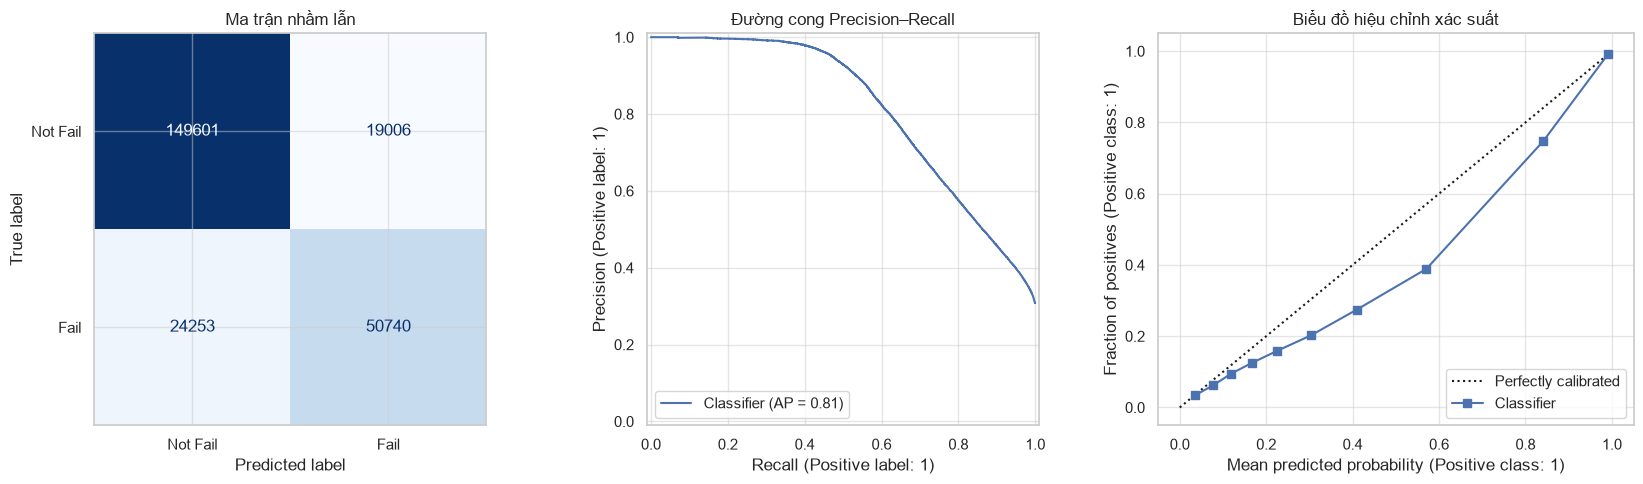

In [49]:
hist_gradient_boosting = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("model", HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    )),
])

hist_gradient_boosting.fit(X_train, y_train)

y_prob = hist_gradient_boosting.predict_proba(X_val)[:, 1]

hist_gradient_boosting_result = evaluate_model(
    y_val,
    y_prob,
    "HistGradientBoosting"
)

#### Kiểm tra overfitting

In [51]:
models = {
    "LogisticRegression": logistic_full,
    "RandomForest": random_forest,
    "HistGradientBoosting": hist_gradient_boosting,
}

rows = []

for name, model in models.items():
    for split, X, y in [
        ("Train", X_train, y_train),
        ("Validation", X_val, y_val),
    ]:
        prob = model.predict_proba(X)[:, 1]
        pred = (prob >= THRESHOLD).astype(int)

        rows.append({
            "model": name,
            "split": split,
            "average_precision": average_precision_score(y, prob),
            "f1_fail": f1_score(y, pred),
            "brier_score": brier_score_loss(y, prob),
        })

overfit_df = pd.DataFrame(rows)
print(overfit_df.round(4))

                  model       split  average_precision  f1_fail  brier_score
0    LogisticRegression       Train             0.8396   0.7150       0.1336
1    LogisticRegression  Validation             0.8067   0.7003       0.1305
2          RandomForest       Train             1.0000   1.0000       0.0066
3          RandomForest  Validation             0.8006   0.6963       0.1330
4  HistGradientBoosting       Train             0.9310   0.8050       0.0904
5  HistGradientBoosting  Validation             0.8128   0.7011       0.1272


Logistic Regression có chênh lệch nhỏ giữa tập Train và Validation nên khả năng tổng quát hóa ổn định nhất. Random Forest đạt kết quả gần tuyệt đối trên Train nhưng giảm rõ rệt trên Validation, cho thấy overfitting mạnh. HistGradientBoosting đạt AP và Brier tốt nhất trên Validation nhưng có chênh lệch Train–Validation lớn hơn Logistic Regression. Vì vậy, loại Random Forest và tiếp tục so sánh Logistic Regression với HistGradientBoosting.

#### Đánh giá mô hình theo tuần

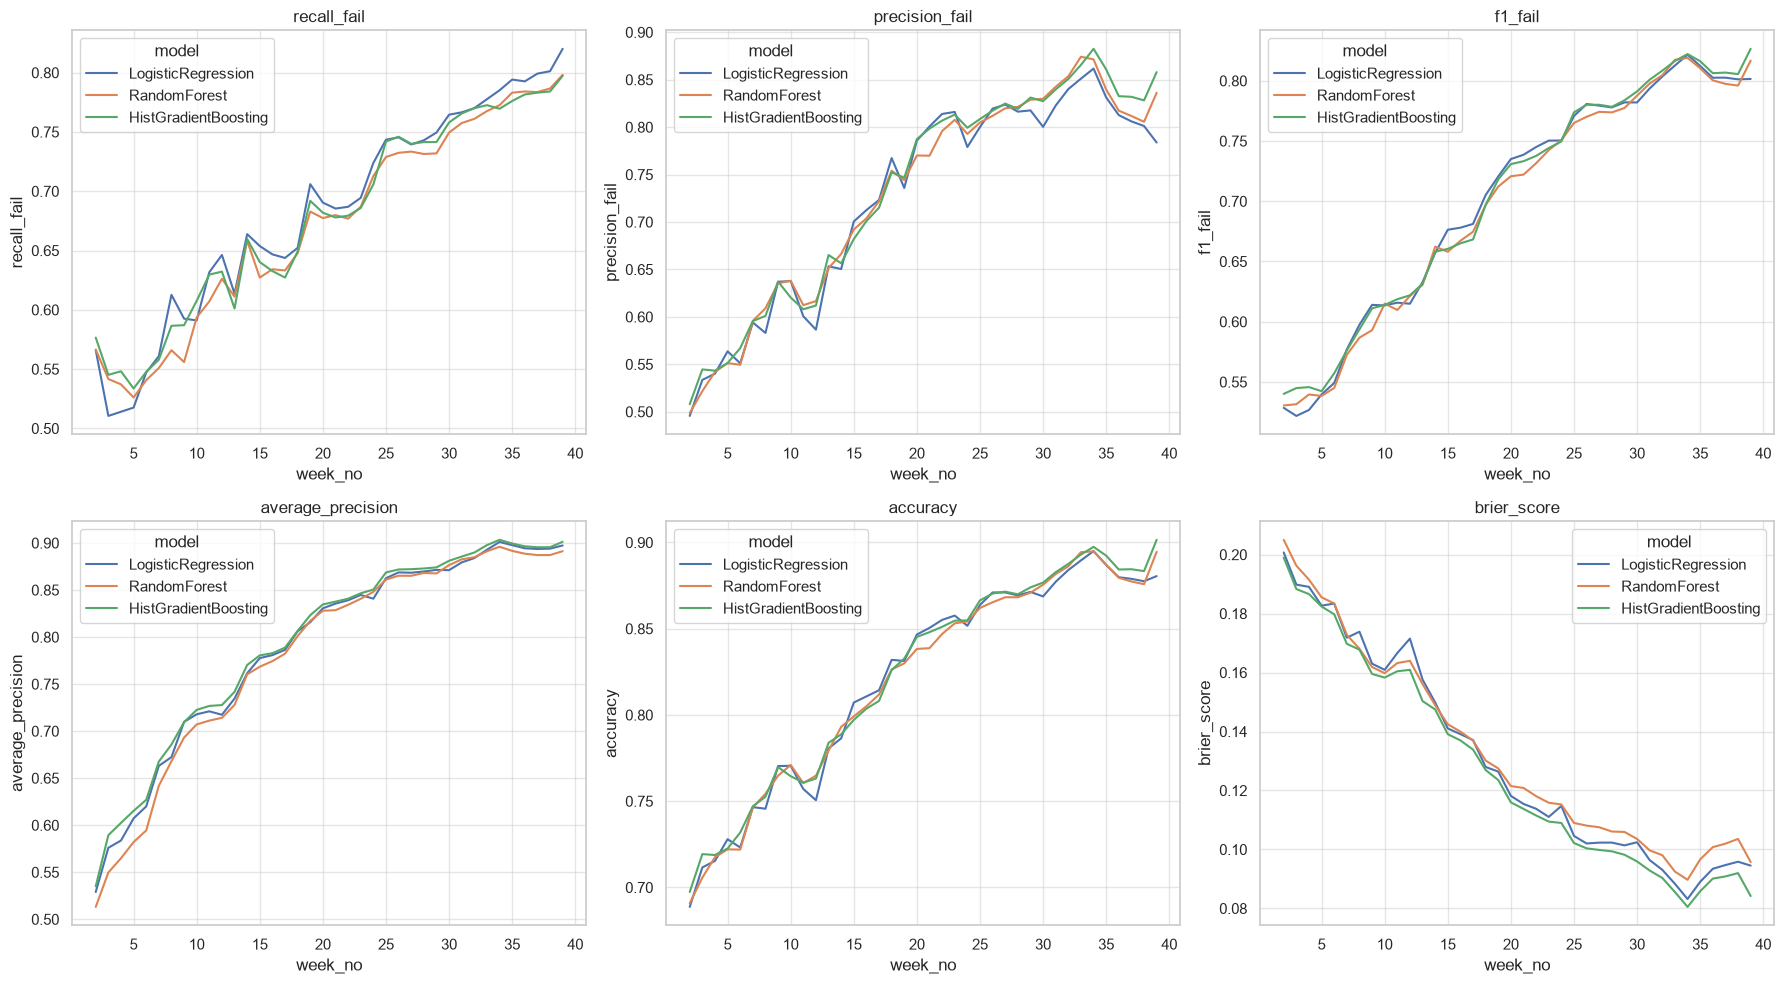

In [52]:
weekly_rows = []

for name, model in models.items():
    prob = model.predict_proba(X_val)[:, 1]

    for week in sorted(X_val["week_no"].unique()):
        mask = X_val["week_no"].eq(week).to_numpy()
        y_week = y_val.to_numpy()[mask]
        prob_week = prob[mask]
        pred_week = (prob_week >= THRESHOLD).astype(int)

        weekly_rows.append({
            "model": name,
            "week_no": week,
            "recall_fail": recall_score(y_week, pred_week),
            "precision_fail": precision_score(y_week, pred_week),
            "f1_fail": f1_score(y_week, pred_week),
            "average_precision": average_precision_score(y_week, prob_week),
            "accuracy": accuracy_score(y_week, pred_week),
            "brier_score": brier_score_loss(y_week, prob_week),
        })

weekly_results = pd.DataFrame(weekly_rows)

metrics = [
    "recall_fail", "precision_fail", "f1_fail",
    "average_precision", "accuracy", "brier_score",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, metric in zip(axes.flat, metrics):
    sns.lineplot(
        data=weekly_results,
        x="week_no",
        y=metric,
        hue="model",
        ax=ax,
    )
    ax.set_title(metric)

plt.tight_layout()
plt.show()

Hiệu quả của cả ba mô hình tăng dần theo tuần: Recall, Precision, F1, AP và Accuracy tăng, trong khi Brier score giảm. Chênh lệch giữa các mô hình khá nhỏ, HistGradientBoosting nhỉnh hơn nhẹ về AP và Brier score. Tuy nhiên, kết quả ở những tuần đầu còn thấp, cho thấy lượng thông tin ban đầu chưa đủ và đây vẫn là hạn chế quan trọng đối với mục tiêu cảnh báo sớm.

=> Không có sự khác biệt lớn giữa các mô hình

#### Chọn mô hình

Trên tập Validation, ba mô hình có các chỉ số và đường Precision–Recall gần tương đương nhau. `HistGradientBoosting` nhỉnh hơn một chút, nhưng hơi có dấu hiệu overfitting; `RandomForest` overfitting mạnh nhất, còn `LogisticRegression` ổn định nhất giữa Train và Validation. Vì sự chênh lệch còn nhỏ, cần đánh giá thêm theo từng tuần trước khi chọn mô hình cuối cùng.

Ba mô hình có kết quả gần tương đương và cùng cải thiện khi tiến gần cuối học phần. `HistGradientBoosting` nhỉnh hơn nhẹ về Average Precision và Brier score, còn `LogisticRegression` ổn định hơn và ít overfitting. `RandomForest` không tạo được lợi thế rõ ràng dù bị overfitting mạnh.

=> Tiếp tục tuning nhẹ `LogisticRegression` và `HistGradientBoosting`; Loại `RandomForest`.

### 4.4 Tinh chỉnh siêu tham số

#### Tuning LogisticRegression

##### Tìm bộ siêu tham số tối ưu bằng GridSearchCV

In [56]:
X_search = np.vstack([X_train_processed, X_val_processed])
y_search = np.concatenate([y_train, y_val])

split = PredefinedSplit(
    [-1] * len(X_train_processed)
    + [0] * len(X_val_processed)
)

common_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "class_weight": [None, "balanced"],
}

lr_param_grid = [
    {
        **common_grid,
        "penalty": ["l2"],
        "solver": ["lbfgs"],
    },
    {
        **common_grid,
        "penalty": ["l1"],
        "solver": ["saga"],
    },
    {
        **common_grid,
        "penalty": ["elasticnet"],
        "solver": ["saga"],
        "l1_ratio": [0.25, 0.5, 0.75],
    },
    {
        "penalty": [None],
        "solver": ["lbfgs"],
        "class_weight": [None, "balanced"],
    },
]

lr_search = GridSearchCV(
    LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
    ),
    param_grid=lr_param_grid,
    scoring=make_scorer(fbeta_score, beta=2, pos_label=1,zero_division=0),
    cv=split,
    refit=False,
    n_jobs=-1,
    verbose=1,
)

lr_search.fit(X_search, y_search)

print("Tham số tốt nhất:", lr_search.best_params_)
print("Validation F2 - score :", round(lr_search.best_score_, 4))

Fitting 1 folds for each of 52 candidates, totalling 52 fits
Tham số tốt nhất: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}
Validation F2 - score : 0.7383


##### Đánh giá lại mô hình trên bộ siêu tham số tối ưu

D:\OU\253\DO_AN_NGANH\WORKSPACE\learning-analytics-pipeline\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


======== Tuned LogisticRegression ========
| Metric            |   Value |
|-------------------|---------|
| threshold         |  0.5    |
| recall_fail       |  0.7866 |
| precision_fail    |  0.5926 |
| f1_fail           |  0.676  |
| f2_fail           |  0.7383 |
| average_precision |  0.807  |
| accuracy          |  0.7679 |
| brier_score       |  0.1536 |


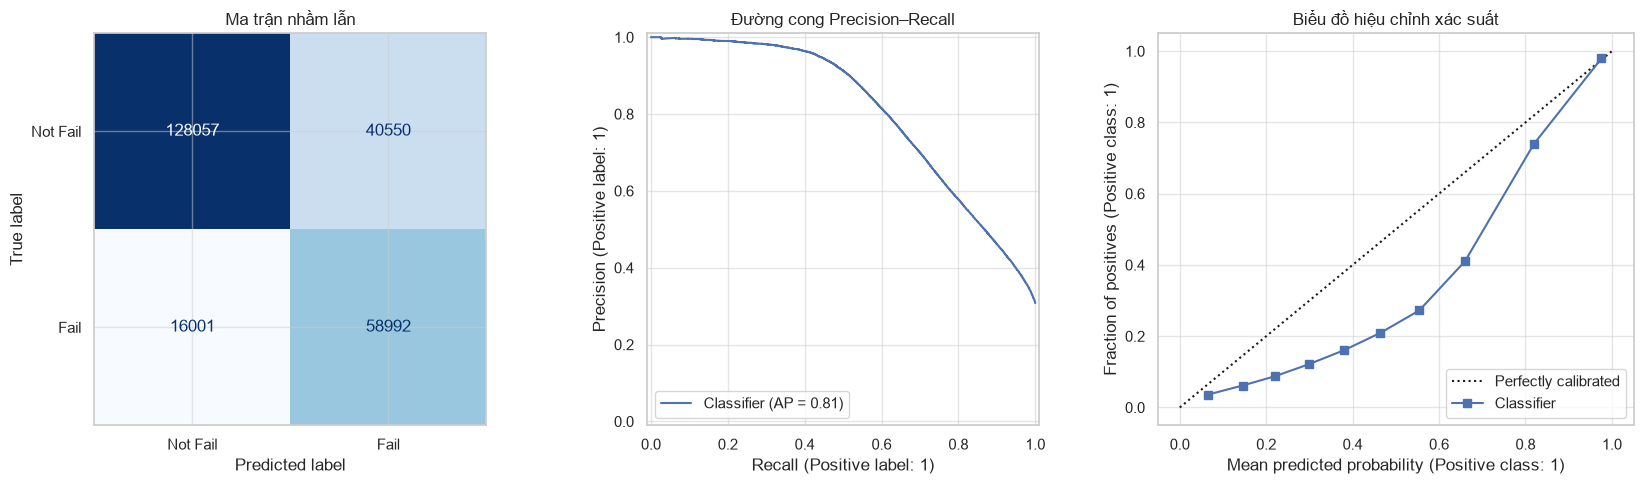

In [57]:
logistic_tuned = clone(logistic_full).set_params(
    model__C=0.01,
    model__class_weight="balanced",
    model__penalty="l2",
    model__solver="lbfgs",
    model__max_iter=2000,
)

logistic_tuned.fit(X_train, y_train)

y_prob = logistic_tuned.predict_proba(X_val)[:, 1]

logistic_tuned_result = evaluate_model(
    y_val,
    y_prob,
    "Tuned LogisticRegression",
)

##### So sánh

In [58]:
print("Cấu hình mặc định:")
print(logistic_full_result)
print("Cấu hình đã tinh chỉnh:")
print(logistic_tuned_result)

Cấu hình mặc định:
{'threshold': 0.5, 'recall_fail': 0.6814102649580628, 'precision_fail': 0.7202599086655015, 'f1_fail': 0.7002966952398572, 'f2_fail': 0.6888412595707969, 'average_precision': 0.8067224031888395, 'accuracy': 0.8204474548440066, 'brier_score': 0.13054941743195272}
Cấu hình đã tinh chỉnh:
{'threshold': 0.5, 'recall_fail': 0.7866334191191178, 'precision_fail': 0.592634264933395, 'f1_fail': 0.6759904890136649, 'f2_fail': 0.7382970308925344, 'average_precision': 0.8069503838832404, 'accuracy': 0.7678530377668309, 'brier_score': 0.15359615961970294}


Cấu hình tinh chỉnh giúp Recall tăng từ 0.6814 lên 0.7866 và F2 tăng từ 0.6888 lên 0.7383, nhưng Precision giảm còn 0.5926 và Brier score tăng lên 0.1536. Trong khi đó, AP gần như không thay đổi. Điều này cho thấy khả năng phân biệt nguy cơ của mô hình không được cải thiện đáng kể; cấu hình mới chủ yếu làm tăng số trường hợp được dự đoán là Fail. Vì vậy, giữ cấu hình Logistic Regression mặc định và điều chỉnh ngưỡng dự đoán ở bước sau sẽ hợp lý hơn.

#### Tuning HistGradientBoosting

##### Tìm bộ siêu tham số tối ưu bằng RandomizedSearchCV

In [59]:
hgb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(
        early_stopping=False,
        random_state=RANDOM_STATE,
    ),
    param_distributions={
        "learning_rate": [0.03, 0.05, 0.1, 0.2],
        "max_iter": [100, 200, 300],
        "max_leaf_nodes": [15, 31, 63],
        "min_samples_leaf": [20, 50, 100],
        "l2_regularization": [0, 0.1, 1, 10],
        "class_weight": [None, "balanced"],
    },
    n_iter=100,
    scoring=make_scorer(fbeta_score, beta=2, pos_label=1,zero_division=0),
    cv=split,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit=False,
    verbose=1,
)

hgb_search.fit(X_search, y_search)

print("Tham số tốt nhất:", hgb_search.best_params_)
print("Validation F2 - score:", round(hgb_search.best_score_, 4))

Fitting 1 folds for each of 100 candidates, totalling 100 fits
Tham số tốt nhất: {'min_samples_leaf': 50, 'max_leaf_nodes': 15, 'max_iter': 200, 'learning_rate': 0.03, 'l2_regularization': 0, 'class_weight': 'balanced'}
Validation Average Precision: 0.7353


##### Đánh giá lại mô hình trên bộ siêu tham số tối ưu

======== Tuned HistGradientBoosting ========
| Metric            |   Value |
|-------------------|---------|
| threshold         |  0.5    |
| recall_fail       |  0.7634 |
| precision_fail    |  0.6409 |
| f1_fail           |  0.6968 |
| f2_fail           |  0.7353 |
| average_precision |  0.8194 |
| accuracy          |  0.7955 |
| brier_score       |  0.1442 |


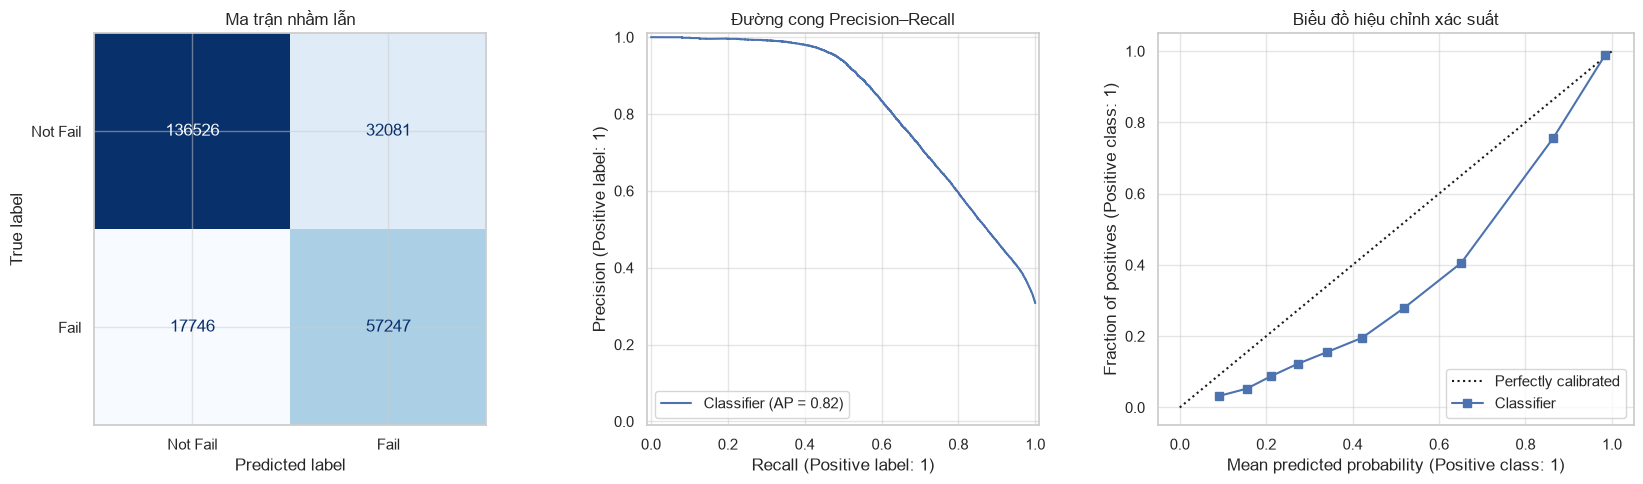

In [60]:
hgb_tuned = clone(hist_gradient_boosting).set_params(
    model__min_samples_leaf=50,
    model__max_leaf_nodes=15,
    model__max_iter=200,
    model__learning_rate=0.03,
    model__l2_regularization=0,
    model__class_weight='balanced',
    model__early_stopping=False
)

hgb_tuned.fit(X_train, y_train)

y_prob = hgb_tuned.predict_proba(X_val)[:, 1]

hgb_tuned_result = evaluate_model(
    y_val,
    y_prob,
    "Tuned HistGradientBoosting"
)

##### So sánh

In [61]:
print("Cấu hình mặc định:")
print(hist_gradient_boosting_result)
print("Cấu hình đã tinh chỉnh:")
print(hgb_tuned_result)

Cấu hình mặc định:
{'threshold': 0.5, 'recall_fail': 0.6765964823383516, 'precision_fail': 0.7274969173859432, 'f1_fail': 0.7011240923317144, 'f2_fail': 0.6861986703379332, 'average_precision': 0.812822144867591, 'accuracy': 0.8224178981937602, 'brier_score': 0.12717465439078762}
Cấu hình đã tinh chỉnh:
{'threshold': 0.5, 'recall_fail': 0.7633645806941981, 'precision_fail': 0.6408628873365574, 'f1_fail': 0.6967703458474571, 'f2_fail': 0.7352555869509376, 'average_precision': 0.8194325788205346, 'accuracy': 0.7954556650246305, 'brier_score': 0.14419021732060464}


Cấu hình tinh chỉnh giúp HistGradientBoosting tăng Recall từ 0.6766 lên 0.7634, F2 từ 0.6862 lên 0.7353 và AP từ 0.8128 lên 0.8194. Precision giảm còn 0.6409 nhưng vẫn trên mức chấp nhận 0.5. Tuy nhiên, Brier score tăng cho thấy chất lượng xác suất dự báo giảm.

=> Cấu hình tinh chỉnh được giữ lại để so sánh ở bước chọn mô hình và khảo sát ngưỡng, nhưng chưa thể kết luận là mô hình cuối cùng.

#### Chọn mô hình cuối cùng

In [62]:
print("Kết quả mô hình LR không cấu hình:")
print(logistic_full_result)
print("Kết quả mô hình HGB có cấu hình:")
print(hgb_tuned_result)

Kết quả mô hình LR không cấu hình:
{'threshold': 0.5, 'recall_fail': 0.6814102649580628, 'precision_fail': 0.7202599086655015, 'f1_fail': 0.7002966952398572, 'f2_fail': 0.6888412595707969, 'average_precision': 0.8067224031888395, 'accuracy': 0.8204474548440066, 'brier_score': 0.13054941743195272}
Kết quả mô hình HGB có cấu hình:
{'threshold': 0.5, 'recall_fail': 0.7633645806941981, 'precision_fail': 0.6408628873365574, 'f1_fail': 0.6967703458474571, 'f2_fail': 0.7352555869509376, 'average_precision': 0.8194325788205346, 'accuracy': 0.7954556650246305, 'brier_score': 0.14419021732060464}


Trên tập Validation, HistGradientBoosting đã tinh chỉnh đạt AP, Recall và F2 cao hơn Logistic Regression, trong khi Precision vẫn lớn hơn 0.5. Mặc dù Logistic Regression có Brier score tốt hơn và dễ giải thích hơn, HistGradientBoosting phù hợp hơn với mục tiêu hạn chế bỏ sót sinh viên Fail.

Chọn HistGradientBoosting đã tinh chỉnh để tiếp tục khảo sát ngưỡng phân loại.

### 4.5 Lựa chọn threshold

In [69]:
y_prob = hgb_tuned.predict_proba(X_val)[:, 1]

rows = []

for threshold in np.arange(0.01, 1, 0.01):
    y_pred = (y_prob >= threshold).astype(int)

    rows.append({
        "threshold": threshold,
        "recall_fail": recall_score(y_val, y_pred),
        "precision_fail": precision_score(
            y_val, y_pred, zero_division=0
        ),
        "f1_fail": f1_score(y_val, y_pred),
        "f2_fail": fbeta_score(y_val, y_pred, beta=2),
    })

threshold_results = pd.DataFrame(rows)

eligible_results = threshold_results[
    threshold_results["precision_fail"] >= 0.5
]

best_result = eligible_results.sort_values(
    ["f2_fail", "recall_fail"],
    ascending=False,
).iloc[0]

best_threshold = best_result["threshold"]

print(best_result.to_frame("value").round(4))

                 value
threshold       0.3500
recall_fail     0.8743
precision_fail  0.5005
f1_fail         0.6366
f2_fail         0.7607


Ngưỡng 0.35 đạt F2 cao nhất nhưng tạo gần 50% cảnh báo nhầm.

Do chưa có dữ liệu thực tế về chi phí và nguồn lực can thiệp, nghiên cứu giữ ngưỡng mặc định 0.5, đồng thời xem việc điều chỉnh ngưỡng theo khả năng hỗ trợ là hướng triển khai thực tế.

## 5. Huấn luyện mô hình cuối cùng và đánh giá

### 5.1 Huấn luyện lại mô hình

Sau khi đã thực hiện huấn luyện, tinh chỉnh và chọn được mô hình phù hợp, cần huấn luyện lại 1 lần trên tập dữ liệu `2013B` và `2013J`.

======== Final HGB ========
| Metric            |   Value |
|-------------------|---------|
| threshold         |  0.5    |
| recall_fail       |  0.7496 |
| precision_fail    |  0.6934 |
| f1_fail           |  0.7204 |
| f2_fail           |  0.7377 |
| average_precision |  0.836  |
| accuracy          |  0.7946 |
| brier_score       |  0.1451 |


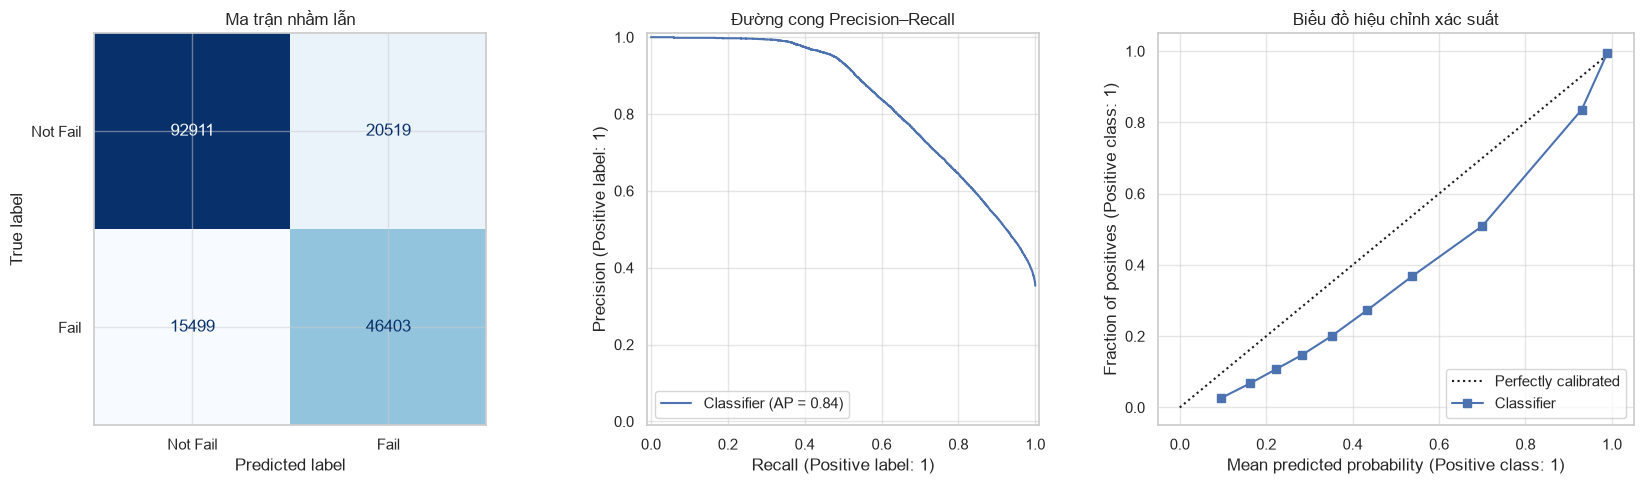

In [76]:
X_train_val = pd.concat([X_train, X_val], ignore_index=True)
y_train_val = pd.concat([y_train, y_val], ignore_index=True)

X_test = test_df.drop(columns=drop_columns)
y_test = test_df["final_result"].map(target_map)

final_model = clone(hgb_tuned)
final_model.fit(X_train_val, y_train_val)

test_prob = final_model.predict_proba(X_test)[:, 1]

final_test_result = evaluate_model(
    y_test,
    test_prob,
    "Final HGB"
)

### 5.2 Đánh giá mô hình theo tuần

In [83]:
weekly_results = []

for week in sorted(test_df["week_no"].unique()):
    mask = test_df["week_no"].eq(week).to_numpy()

    y_week = y_test.to_numpy()[mask]
    prob_week = test_prob[mask]
    pred_week = (prob_week >= 0.5).astype(int)

    weekly_results.append({
        "week_no": week,
        "recall_fail": recall_score(y_week, pred_week),
        "precision_fail": precision_score(
            y_week, pred_week, zero_division=0
        ),
        "f1_fail": f1_score(y_week, pred_week),
        "f2_fail": fbeta_score(y_week, pred_week, beta=2, pos_label=1,zero_division=0),
        "average_precision": average_precision_score(y_week, prob_week),
        "accuracy": accuracy_score(y_week, pred_week),
        "brier_score": brier_score_loss(y_week, prob_week),
    })

weekly_test_results = pd.DataFrame(weekly_results)

weekly_test_results.round(4)

,week_no,recall_fail,precision_fail,f1_fail,f2_fail,average_precision,accuracy,brier_score
0,2,0.6860,0.5293,0.5976,0.6477,0.6212,0.6741,0.2101
1,3,0.6862,0.5307,0.5985,0.6482,0.6359,0.6752,0.2070
2,4,0.6776,0.5482,0.6061,0.6470,0.6714,0.6892,0.1980
3,5,0.6978,0.5495,0.6148,0.6621,0.6830,0.6915,0.1971
4,6,0.7187,0.5744,0.6385,0.6843,0.7113,0.7128,0.1907
5,7,0.7247,0.5538,0.6279,0.6826,0.6986,0.6968,0.1970
6,8,0.6892,0.6067,0.6454,0.6710,0.7474,0.7327,0.1772
7,9,0.6960,0.6281,0.6603,0.6812,0.7657,0.7472,0.1718
8,10,0.6834,0.6593,0.6711,0.6784,0.7848,0.7635,0.1623
9,11,0.6992,0.6627,0.6805,0.6916,0.7905,0.7682,0.1623


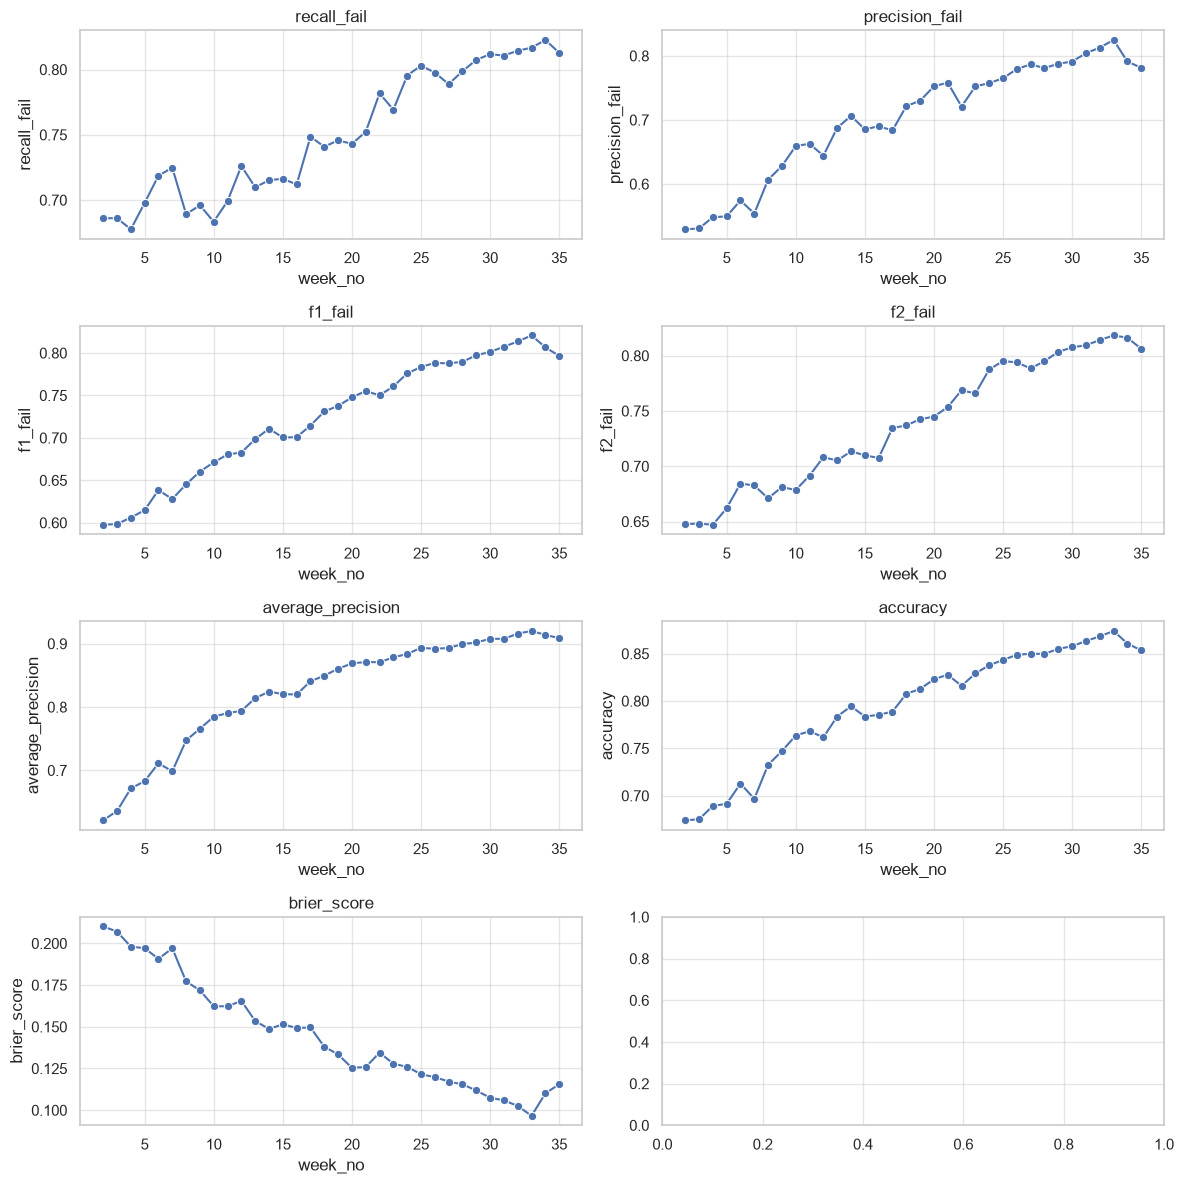

In [99]:
fig, axes = plt.subplots(4, 2, figsize=(12, 12))
scores = [
    "recall_fail",
    "precision_fail",
    "f1_fail",
    "f2_fail",
    "average_precision",
    "accuracy",
    "brier_score"
]

for ax, score in zip(axes.flat, scores):
    sns.lineplot(
        data=weekly_test_results,
        x="week_no",
        y=score,
        marker="o",
        ax=ax,
    )
    ax.set_title(score)

plt.tight_layout()
plt.show()


Kết quả đánh giá theo tuần cho thấy:

- **Tuần 2–7:** Recall đạt khoảng 0.68–0.72 nhưng Precision chỉ khoảng 0.53–0.57. F2 dao động từ 0.6470 đến 0.6843 và cao hơn F1 do chỉ số này ưu tiên khả năng phát hiện sinh viên `Fail`. Mô hình đã có giá trị cảnh báo sớm nhưng số cảnh báo nhầm còn tương đối cao.
- **Tuần 8–17:** hiệu quả cải thiện dần khi có thêm dữ liệu học tập. AP tăng từ 0.7474 lên 0.8407, còn F2 tăng từ 0.6710 lên 0.7346.
- **Tuần 18–33:** mô hình đạt kết quả tốt và ổn định hơn. F2 tăng từ 0.7369 lên mức cao nhất 0.8183 tại tuần 33; đồng thời AP đạt 0.9201 và Brier score giảm còn 0.0966.
- **Tuần 34–35:** các chỉ số giảm nhẹ so với tuần 33 nhưng F2 vẫn duy trì trên 0.80.

Vậy, khả năng phát hiện sinh viên `Fail` tăng dần theo thời gian. Mô hình có thể hỗ trợ cảnh báo từ những tuần đầu, nhưng Precision còn hạn chế; hiệu quả cao ở các tuần sau phải đánh đổi bằng việc giảm thời gian dành cho can thiệp.

### 5.3 Đánh giá theo module


In [91]:
hgb_prob = final_model.predict_proba(X_test)[:, 1]
hgb_pred = (hgb_prob >= 0.5).astype(int)
y_test_array = y_test.to_numpy()

module_rows = []

for module in sorted(test_df["code_module"].unique()):
    mask = test_df["code_module"].eq(module).to_numpy()

    module_rows.append({
        "code_module": module,
        "sample_count": mask.sum(),
        "fail_rate": y_test_array[mask].mean(),
        "recall_fail": recall_score(
            y_test_array[mask], hgb_pred[mask]
        ),
        "precision_fail": precision_score(
            y_test_array[mask], hgb_pred[mask],
            zero_division=0,
        ),
        "f1_fail": f1_score(
            y_test_array[mask], hgb_pred[mask]
        ),
        "f2_fail": fbeta_score(
            y_test_array[mask], hgb_pred[mask],
            beta=2,
            zero_division=0,
        ),
        "average_precision": average_precision_score(
            y_test_array[mask], hgb_prob[mask]
        ),
        "accuracy": accuracy_score(
            y_test_array[mask], hgb_pred[mask]
        ),
        "brier_score": brier_score_loss(
            y_test_array[mask], hgb_prob[mask]
        ),
    })

module_results = pd.DataFrame(module_rows)
module_results.round(4)

,code_module,sample_count,fail_rate,recall_fail,precision_fail,f1_fail,f2_fail,average_precision,accuracy,brier_score
0,BBB,37037,0.3524,0.7679,0.6826,0.7228,0.7492,0.8436,0.7924,0.1467
1,CCC,35292,0.3613,0.7615,0.6051,0.6743,0.7241,0.8054,0.7343,0.1845
2,DDD,25080,0.3510,0.7531,0.7342,0.7435,0.7492,0.8464,0.8176,0.1333
3,EEE,17714,0.3148,0.7032,0.7758,0.7377,0.7166,0.8476,0.8426,0.1201
4,FFF,35287,0.3699,0.7380,0.7989,0.7672,0.7494,0.8777,0.8344,0.1202
5,GGG,24922,0.3479,0.7486,0.6455,0.6932,0.7254,0.8195,0.7695,0.1517


Kết quả theo từng học phần cho thấy:

- **FFF** đạt kết quả tốt nhất với F1 0.7672, F2 0.7494 và AP 0.8777.
- **BBB và DDD** có Recall và Precision tương đối cân bằng.
- **EEE** có Precision cao nhưng Recall thấp nhất. **CCC và GGG** có Precision thấp hơn; trong đó CCC có Brier score cao nhất, cho thấy chất lượng xác suất dự báo còn hạn chế.

Vậy, mô hình hoạt động khá tốt trên phần lớn học phần nhưng hiệu quả chưa đồng đều, đặc biệt cần lưu ý học phần CCC và GGG.

## 6. Giải thích mô hình

.values =
array([[ 6.89677232e-02, -1.84718560e-04,  4.14314080e-04, ...,
         6.49205413e-01, -4.37182502e-02,  2.38209313e+00],
       [-1.18897914e-01, -2.05983091e-04,  1.56075226e-03, ...,
         1.78350002e-01, -1.16012499e-01, -6.80086228e-01],
       [-1.03821601e-01, -5.68364793e-05,  2.02945232e-03, ...,
        -9.81272244e-02,  1.42934636e-01, -5.87117534e-01],
       ...,
       [ 8.79174180e-02, -1.84718560e-04,  9.93059539e-04, ...,
         1.42320236e-01, -1.24208513e-01, -8.01836262e-01],
       [ 2.68206474e-02, -1.84718560e-04,  2.70690769e-06, ...,
         6.57362603e-01,  4.43787849e-02,  2.29170929e+00],
       [ 4.50173278e-02, -2.05983091e-04,  3.94730724e-04, ...,
        -1.36108038e-01, -2.31536829e-01, -6.68860137e-01]],
      shape=(1000, 33))

.base_values =
array([0.21179552, 0.21179552, 0.21179552, 0.21179552, 0.21179552,
       0.21179552, 0.21179552, 0.21179552, 0.21179552, 0.21179552,
       0.21179552, 0.21179552, 0.21179552, 0.21179552, 0.21

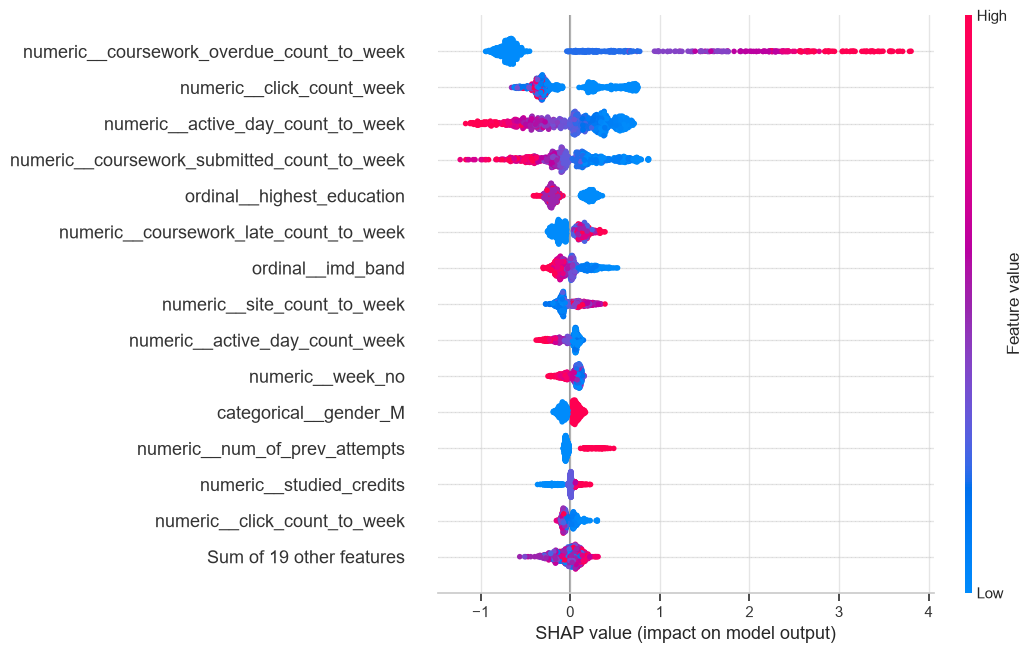

In [93]:
preprocessor = final_model.named_steps["preprocessor"]
classifier = final_model.named_steps["model"]

background_raw = X_train_val.sample(
    100,
    random_state=RANDOM_STATE,
)

explain_raw = X_test.sample(
    1000,
    random_state=RANDOM_STATE,
)

background = preprocessor.transform(background_raw)
X_explain = preprocessor.transform(explain_raw)

explainer = shap.Explainer(
    classifier,
    background,
    feature_names=preprocessor.get_feature_names_out(),
)

shap_values = explainer(X_explain, check_additivity=False)

print(shap_values)

shap.plots.beeswarm(
    shap_values,
    max_display=15,
)

## 7. Lưu mô hình

In [97]:
fitted_preprocessor = final_model.named_steps["preprocessor"]
classifier = final_model.named_steps["model"]

artifact = {
    "model": final_model,
    "threshold": THRESHOLD,
    "shap_background": fitted_preprocessor.transform(
        X_train_val.sample(100, random_state=RANDOM_STATE)
    ),
    "metadata": {
        "model_name": type(classifier).__name__,
        "hyperparameters": classifier.get_params(),
        "target": "final_result",
        "target_mapping": {
            "Fail": 1,
            "Pass": 0,
            "Distinction": 0,
        },
        "excluded_class": "Withdrawn",
        "prediction_unit": "student-module-presentation-week",
        "first_prediction_week": 2,
        "training_presentations": ["2013B", "2013J"],
        "test_presentation": "2014B",
        "random_state": RANDOM_STATE,
        "raw_features": X_train_val.columns.tolist(),
        "processed_features": (
            fitted_preprocessor.get_feature_names_out().tolist()
        ),
        "test_metrics": final_test_result,
        "created_at": datetime.now().astimezone().isoformat(
            timespec="seconds"
        ),
    },
}

artifact_path = "../models/final_model.joblib"
jb.dump(artifact, artifact_path)

print(f"Đã lưu '{artifact_path}.'")

Đã lưu '../models/final_model.joblib.'


In [100]:
artifact = jb.load("../models/final_model.joblib")

model = artifact["model"]
threshold = artifact["threshold"]
preprocessor = model.named_steps["preprocessor"]
classifier = model.named_steps["model"]
feature_names = artifact["metadata"]["processed_features"]

# Chỉ lấy 1.000 dòng để minh họa trong notebook
sample_positions = np.random.default_rng(RANDOM_STATE).choice(
    len(X_test),
    size=min(1000, len(X_test)),
    replace=False,
)

X_sample = X_test.iloc[sample_positions]
prediction_df = test_df.iloc[sample_positions].copy()

sample_prob = model.predict_proba(X_sample)[:, 1]
X_processed = preprocessor.transform(X_sample)

assert X_processed.shape[1] == len(feature_names)
assert X_processed.shape[1] == classifier.n_features_in_

explainer = shap.Explainer(
    classifier,
    artifact["shap_background"],
    feature_names=feature_names,
)

shap_values = explainer(
    X_processed,
    check_additivity=False,
)

top_3 = np.argsort(
    -np.abs(shap_values.values),
    axis=1,
)[:, :3]


def explain_row(i):
    factors = {}

    for j in top_3[i]:
        group, name = feature_names[j].split("__", 1)

        value = (
            int(X_processed[i, j])
            if group == "categorical"
            or name.startswith("missingindicator_")
            else X_sample.iloc[i][name]
        )

        factors[name] = {
            "value": None if pd.isna(value) else value,
            "contribution": round(
                float(shap_values.values[i, j]),
                4,
            ),
        }

    return factors


prediction_df["probability_fail"] = sample_prob
prediction_df["prediction"] = np.where(
    sample_prob >= threshold,
    "Fail",
    "Not Fail",
)
prediction_df["top_3_factors"] = [
    explain_row(i)
    for i in range(len(X_sample))
]

prediction_df.head()

,module_presentation_student_week_id,id_student,code_module,code_presentation,week_no,gender,region,highest_education,imd_band,age_band,...,activity_type_count_to_week,coursework_due_count_to_week,coursework_submitted_count_week,coursework_submitted_count_to_week,coursework_late_count_to_week,coursework_overdue_count_to_week,final_result,probability_fail,prediction,top_3_factors
454985,722685,606407,FFF,2014B,18,M,Yorkshire Region,A Level or Equivalent,0-10%,35-55,...,9,3,0,1,1,2,Fail,0.978157,Fail,{'coursework_overdue_count_to_week': {'value':...
464612,733450,628143,FFF,2014B,23,F,East Midlands Region,A Level or Equivalent,20-30%,0-35,...,10,4,0,3,1,1,Fail,0.848815,Fail,"{'click_count_week': {'value': 0, 'contributio..."
276589,444068,613834,DDD,2014B,14,M,South Region,A Level or Equivalent,40-50%,35-55,...,9,3,0,3,0,0,Pass,0.206909,Not Fail,{'coursework_overdue_count_to_week': {'value':...
443531,709609,353979,FFF,2014B,18,M,London Region,Lower Than A Level,20-30%,0-35,...,7,3,1,6,1,0,Fail,0.400266,Not Fail,{'coursework_overdue_count_to_week': {'value':...
182031,272240,633112,CCC,2014B,16,F,London Region,A Level or Equivalent,90-100%,35-55,...,8,4,0,2,2,2,Distinction,0.564593,Fail,{'coursework_overdue_count_to_week': {'value':...
